<a href="https://colab.research.google.com/github/krasnovaov81-coder/netology/blob/main/final_project_tmdb_stat_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 **Итоговая работа. Анализ кинокассовых сборов**

**Датасет:** [TMDB 5000 Movie Dataset](https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata)

---

Вы — аналитик в крупной киностудии. Руководство планирует новый фильм и хочет принять решение о бюджете, жанре и стратегии релиза на основе данных, а не интуиции.

В вашем распоряжении — база данных **TMDB** (The Movie Database) с информацией о тысячах фильмов: бюджеты, кассовые сборы, оценки зрителей, жанры и другие характеристики.

## 🎯 Задачи

Работа состоит из **трёх частей**:

| Часть | Тема | Вес |
|-------|------|-----|
| **1. EDA** | Исследовательский анализ данных | ~40% |
| **2. Корреляция** | Анализ взаимосвязей между признаками | ~25% |
| **3. Гипотезы** | Проверка статистических гипотез | ~35% |

## 📊 Описание датасета

**Ключевые признаки:**

| Признак | Описание |
|---------|----------|
| `budget` | Бюджет фильма (USD) |
| `revenue` | Мировые кассовые сборы (USD) |
| `vote_average` | Средняя оценка зрителей (0–10) |
| `vote_count` | Количество голосов |
| `runtime` | Длительность (минуты) |
| `release_date` | Дата выхода |
| `genres` | Жанры (строка в формате JSON) |
| `original_language` | Язык оригинала (код: ``en``, ``fr``, ``ja``, ...) |
| `popularity` | Индекс популярности TMDB |
| `title` | Название фильма |
| `tagline` | Слоган фильма |
| `overview` | Краткое описание |
| `homepage` | Сайт фильма |
| `status` | Статус (Released, Post Production, ...) |

## ✏️ Требования к оформлению графиков

- У каждого графика должен быть **заголовок** (``plt.title()``)
- Подписаны **оси** (``plt.xlabel()``, ``plt.ylabel()``)
- Легенда — при наличии нескольких элементов
- Оставляйте **комментарии и выводы** к каждому разделу


---
# **Часть 1. Исследовательский анализ данных (EDA)**
---

## **1. Импорт библиотек и загрузка данных**

Импортируйте библиотеки и загрузите датасет.

In [ ]:
import json

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (11, 6)

# Загрузка датасета
path = kagglehub.dataset_download("tmdb/tmdb-movie-metadata")
df = pd.read_csv(f"{path}/tmdb_5000_movies.csv")

df.head()

Using Colab cache for faster access to the 'tmdb-movie-metadata' dataset.


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


## **2. Первичный осмотр данных**

Проведите инвентаризацию датасета. Ответьте на вопросы:
- Сколько строк и столбцов?
- Какие типы данных у каждого столбца? Есть ли некорректные типы?
- Как выглядят базовые статистики числовых признаков?
- Какие проблемы в данных вы видите?


In [ ]:
# Ваш код здесь:
print("Размер датасета:", df.shape)

print("\nТипы данных:")
display(df.dtypes)

print("\nИнформация о DataFrame:")
df.info()

print("\nОписательная статистика числовых признаков:")
display(df.describe().T)

print("\nПервые строки:")
display(df.head())

Размер датасета: (4803, 20)

Типы данных:


,0
budget,int64
genres,object
homepage,object
id,int64
keywords,object
original_language,object
original_title,object
overview,object
popularity,float64
production_companies,object



Информация о DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 

,count,mean,std,min,25%,50%,75%,max
budget,4803.0,2.904504e+07,4.072239e+07,0.0,790000.00000,1.500000e+07,4.000000e+07,3.800000e+08
id,4803.0,5.716548e+04,8.869461e+04,5.0,9014.50000,1.462900e+04,5.861050e+04,4.594880e+05
popularity,4803.0,2.149230e+01,3.181665e+01,0.0,4.66807,1.292159e+01,2.831350e+01,8.755813e+02
revenue,4803.0,8.226064e+07,1.628571e+08,0.0,0.00000,1.917000e+07,9.291719e+07,2.787965e+09
runtime,4801.0,1.068759e+02,2.261193e+01,0.0,94.00000,1.030000e+02,1.180000e+02,3.380000e+02
vote_average,4803.0,6.092172e+00,1.194612e+00,0.0,5.60000,6.200000e+00,6.800000e+00,1.000000e+01
vote_count,4803.0,6.902180e+02,1.234586e+03,0.0,54.00000,2.350000e+02,7.370000e+02,1.375200e+04



Первые строки:


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


**Ваши наблюдения по первичному осмотру:**

Датасет содержит 4 803 строки и 20 столбцов.

Числовые признаки:
- budget, id, popularity, revenue, runtime, vote_average, vote_count.
- release_date, genres, keywords, production_companies, production_countries, spoken_languages, status, tagline, title, original_language — строковые (object).

Ключевые проблемы:
- homepage, tagline, overview, release_date, runtime имеют пропуски.
- budget, revenue, runtime, vote_count, vote_average содержат нули, которые, скорее всего, означают отсутствие данных.
- release_date имеет тип object и требует преобразования в datetime.

## **3. Качество данных**

Исследуйте полноту и чистоту данных:
- В каких столбцах есть пропуски? Какова их доля (в %)?
- Есть ли полные дубликаты строк?
- Сколько фильмов имеют ``budget == 0``? А ``revenue == 0``?
- Что означают нулевые значения в ``budget`` и ``revenue``? Примите решение, что с ними делать.



In [ ]:
# Ваш код здесь:
# Количество и доля пропусков
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
}).sort_values("missing_percent", ascending=False)

display(missing[missing["missing_count"] > 0])

# Полные дубликаты
print("Полные дубликаты:", df.duplicated().sum())

# Нулевые значения в финансовых показателях
zero_budget = (df["budget"] == 0).sum()
zero_revenue = (df["revenue"] == 0).sum()
zero_runtime = (df["runtime"] == 0).sum()
zero_vote_count = (df["vote_count"] == 0).sum()
zero_vote_average = (df["vote_average"] == 0).sum()

print(f"budget == 0: {zero_budget} ({zero_budget / len(df) * 100:.2f}%)")
print(f"revenue == 0: {zero_revenue} ({zero_revenue / len(df) * 100:.2f}%)")
print(f"runtime == 0: {zero_runtime} ({zero_runtime / len(df) * 100:.2f}%)")
print(f"vote_count == 0: {zero_vote_count} ({zero_vote_count / len(df) * 100:.2f}%)")
print(f"vote_average == 0: {zero_vote_average} ({zero_vote_average / len(df) * 100:.2f}%)")

,missing_count,missing_percent
homepage,3091,64.36
tagline,844,17.57
overview,3,0.06
runtime,2,0.04
release_date,1,0.02


Полные дубликаты: 0
budget == 0: 1037 (21.59%)
revenue == 0: 1427 (29.71%)
runtime == 0: 35 (0.73%)
vote_count == 0: 62 (1.29%)
vote_average == 0: 63 (1.31%)


**Найденные проблемы и ваши наблюдения:**

Пропуски (NaN):
- homepage: 3 091 (64,36%) — критически много, это текстовое поле несущественно для финансового анализа.
- tagline: 844 (17,57%) — текстовое поле, не критично.
- overview: 3 (0,06%) — минимально.
- runtime: 2 (0,04%) — важно для анализа длительности.
- release_date: 1 (0,02%) — важно для временного анализа.

Нулевые значения (0):
- budget == 0: 1 037 (21,59%) — более 1/5 фильмов без данных о бюджете, характерно для независимых/малобюджетных фильмов.
- revenue == 0: 1 427 (29,71%) — почти 30% без данных о сборах (фильм не вышел или данные не собраны).
- runtime == 0: 35 (0,73%) — явный артефакт.
- vote_count == 0: 62 (1,29%) — нет голосов.
- vote_average == 0: 63 (1,31%) — нет средней оценки.

Дубликаты: полные дубликаты строк отсутствуют (0).

## **4. Очистка и подготовка данных**

Подготовьте данные к анализу.

**Обязательные шаги:**
1. Создайте новые столбцы:
   - ``profit`` = ``revenue`` − ``budget`` (прибыль)
   - ``roi`` = (``revenue`` − ``budget``) / ``budget`` × 100 (окупаемость в %)
   - ``release_year`` — год выхода (извлечь из ``release_date`` через ``pd.to_datetime().dt.year``)
2. Обработайте пропуски в ``runtime`` (если есть)



In [ ]:
# Ваш код здесь:

# Копируем, чтобы не портить исходник
df_clean = df.copy()

# -------------------------------------------------
# 1. Дата релиза и год
# -------------------------------------------------
df_clean["release_date"] = pd.to_datetime(
    df_clean["release_date"],
    errors="coerce"
)
df_clean["release_year"] = df_clean["release_date"].dt.year

# -------------------------------------------------
# 2. Обработка нулей как пропусков
# -------------------------------------------------
cols_zero_to_nan = ["budget", "revenue", "runtime", "vote_count", "vote_average"]

for col in cols_zero_to_nan:
    df_clean[col] = df_clean[col].replace(0, np.nan)

# -------------------------------------------------
# 3. Заполнение пропусков в runtime (медианой)
# -------------------------------------------------
runtime_median = df_clean["runtime"].median()
df_clean["runtime"] = df_clean["runtime"].fillna(runtime_median)

# -------------------------------------------------
# 4. Прибыль и ROI
# -------------------------------------------------
df_clean["profit"] = df_clean["revenue"] - df_clean["budget"]

df_clean["roi"] = (
    (df_clean["revenue"] - df_clean["budget"])
    / df_clean["budget"]
    * 100
)

# -------------------------------------------------
# 5. Извлечение основного жанра
# -------------------------------------------------
def get_primary_genre(genres_string):
    if not isinstance(genres_string, str):
        return np.nan
    try:
        genres = json.loads(genres_string)
        if isinstance(genres, list) and len(genres) > 0:
            return genres[0]["name"]
    except (json.JSONDecodeError, KeyError, TypeError, IndexError):
        pass
    return np.nan

df_clean["primary_genre"] = df_clean["genres"].apply(get_primary_genre)

# -------------------------------------------------
# 6. Фильтрация для финансового анализа и ROI
# -------------------------------------------------
df_finance = (
    df_clean
    .query("budget > 0")
    .query("revenue > 0")
    .query("roi.notna()")
    .copy()
)

# Отсечение экстремальных ROI (микробюджеты, аномалии)
df_finance = df_finance[
    df_finance["roi"].between(-10000, 10000)
]

# -------------------------------------------------
# 7. Набор данных для корреляций и гипотез
# -------------------------------------------------
df_analysis = (
    df_clean
    .query("budget > 0")
    .query("revenue > 0")
    .dropna(subset=["vote_average", "vote_count", "runtime"])
    .copy()
)

# Проверка результата
print("Размер df_clean:", df_clean.shape)
print("Размер df_finance (для ROI):", df_finance.shape)
print("Размер df_analysis (для корреляций и гипотез):", df_analysis.shape)

display(
    df_clean[
        ["title", "budget", "revenue", "profit", "roi",
         "release_date", "release_year", "runtime",
         "vote_average", "vote_count", "primary_genre"]
    ].head()
)

Размер df_clean: (4803, 24)
Размер df_finance (для ROI): (3204, 24)
Размер df_analysis (для корреляций и гипотез): (3227, 24)


,title,budget,revenue,profit,roi,release_date,release_year,runtime,vote_average,vote_count,primary_genre
0,Avatar,237000000.0,2.787965e+09,2.550965e+09,1076.356577,2009-12-10,2009.0,162.0,7.2,11800.0,Action
1,Pirates of the Caribbean: At World's End,300000000.0,9.610000e+08,6.610000e+08,220.333333,2007-05-19,2007.0,169.0,6.9,4500.0,Adventure
2,Spectre,245000000.0,8.806746e+08,6.356746e+08,259.459024,2015-10-26,2015.0,148.0,6.3,4466.0,Action
3,The Dark Knight Rises,250000000.0,1.084939e+09,8.349391e+08,333.975640,2012-07-16,2012.0,165.0,7.6,9106.0,Action
4,John Carter,260000000.0,2.841391e+08,2.413910e+07,9.284269,2012-03-07,2012.0,132.0,6.1,2124.0,Action


**Опишите, что вы сделали и почему:**

- release_date преобразован в datetime, извлечён release_year для временного анализа.
- Нули в budget, revenue, runtime, vote_count, vote_average заменены на NaN, так как это отсутствие данных, а не реальные значения (согласно описанию датасета).
- Пропуски в runtime заполнены медианой (устойчива к выбросам).
- Созданы profit (прибыль) и roi (окупаемость в %).
- Извлечён primary_genre из JSON-строки genres.
- Отфильтрованы фильмы без данных о бюджете/сборах для финансового анализа.
- Отсечены экстремальные значения ROI (±10 000%), чтобы избежать искажения от микробюджетов.

## **5. Анализ распределений**

Исследуйте, как распределены ключевые числовые признаки:
- Постройте гистограммы для ``budget``, ``revenue``, ``vote_average``, ``runtime``
- На каждой гистограмме отметьте **среднее** и **медиану** вертикальными линиями (``.axvline()``)
- Сравните среднее и медиану — сильно ли они различаются? О чём это говорит?
- Постройте boxplot для поиска выбросов



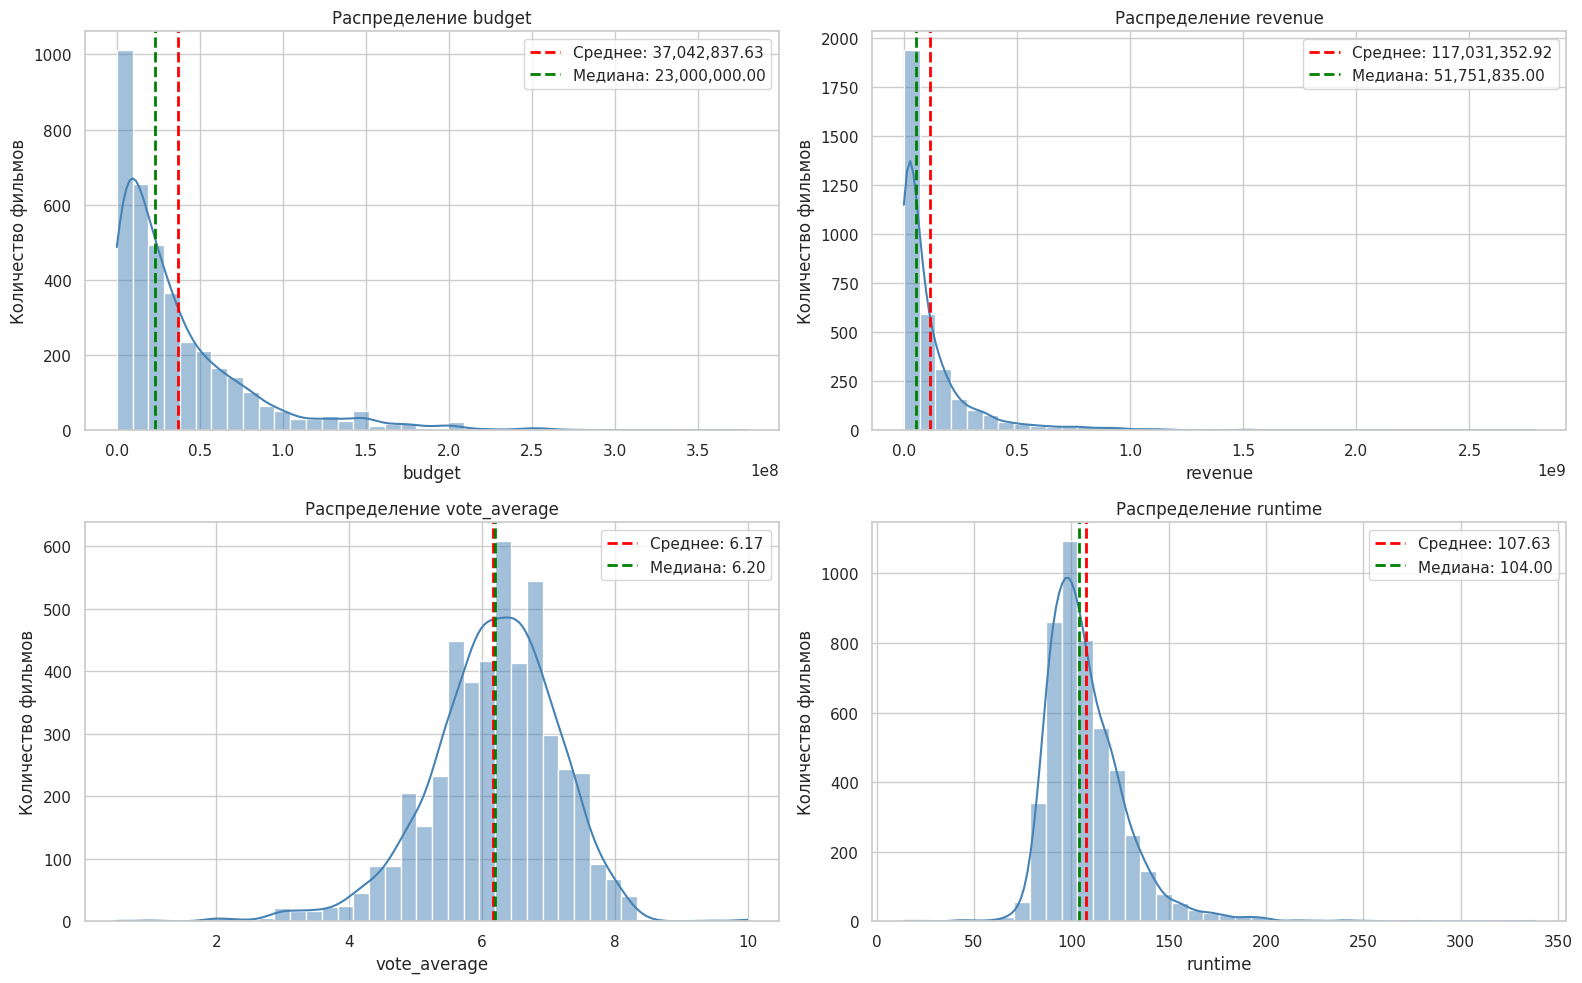

In [ ]:
# Ваш код здесь:
features = ["budget", "revenue", "vote_average", "runtime"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, features):
    data = df_clean[col].dropna()

    sns.histplot(data, bins=40, kde=True, ax=ax, color="steelblue")

    mean_value = data.mean()
    median_value = data.median()

    ax.axvline(
        mean_value,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Среднее: {mean_value:,.2f}"
    )
    ax.axvline(
        median_value,
        color="green",
        linestyle="--",
        linewidth=2,
        label=f"Медиана: {median_value:,.2f}"
    )

    ax.set_title(f"Распределение {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Количество фильмов")
    ax.legend()

plt.tight_layout()
plt.show()

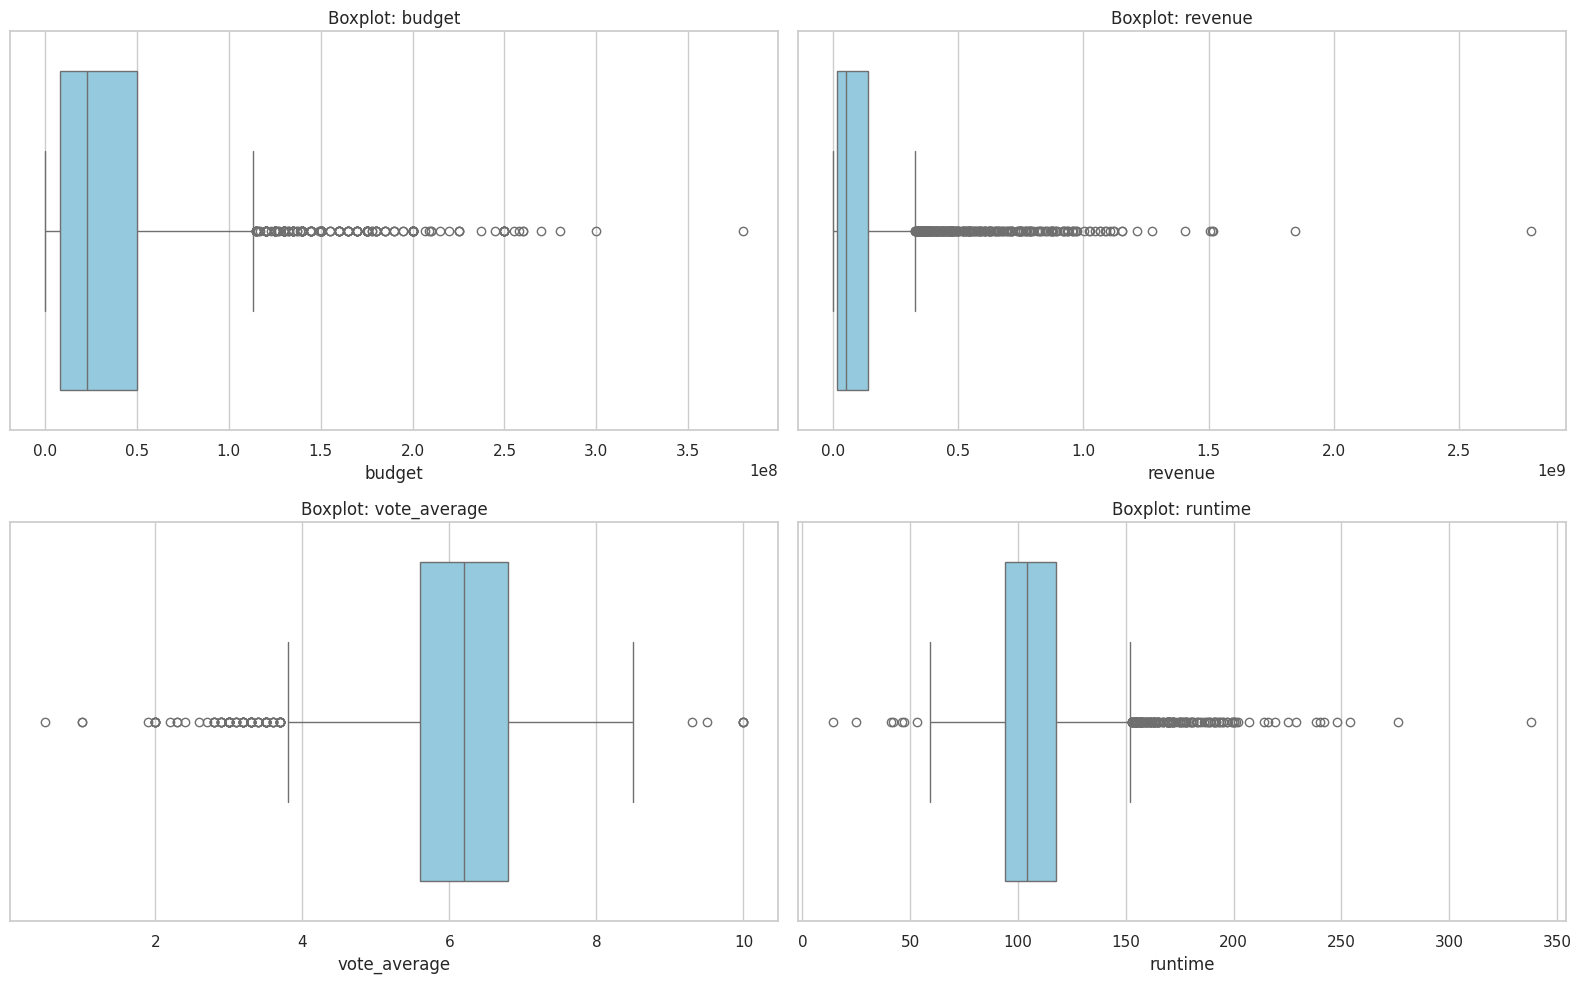

In [ ]:
# Boxplot для поиска выбросов
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, features):
    sns.boxplot(x=df_clean[col], ax=ax, color="skyblue")
    ax.set_title(f"Boxplot: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

**Какие закономерности вы видите? Какие распределения скошены? Где выбросы?**

Наблюдения по распределениям
budget: среднее значительно выше медианы → правосторонняя асимметрия, много малобюджетных фильмов и несколько блокбастеров.

revenue: ещё более сильная асимметрия, несколько суперхитов завышают среднее.

vote_average: распределение близкое к симметричному, основная масса оценок в диапазоне 5,6–6,8.

runtime: распределение вокруг 90–120 минут, есть экстремально длинные фильмы.

Выбросы ожидаются в budget, revenue, popularity, vote_count.

## **6. Исследовательские вопросы**

Ответьте на **минимум 5 из 6** вопросов ниже. Для каждого вопроса:
- Напишите код для получения ответа
- Постройте подходящую визуализацию
- Сформулируйте краткий вывод

### Вопрос 1. Какие жанры представлены чаще всего?

Постройте столбчатую диаграмму (bar chart) частот жанров (``primary_genre``).

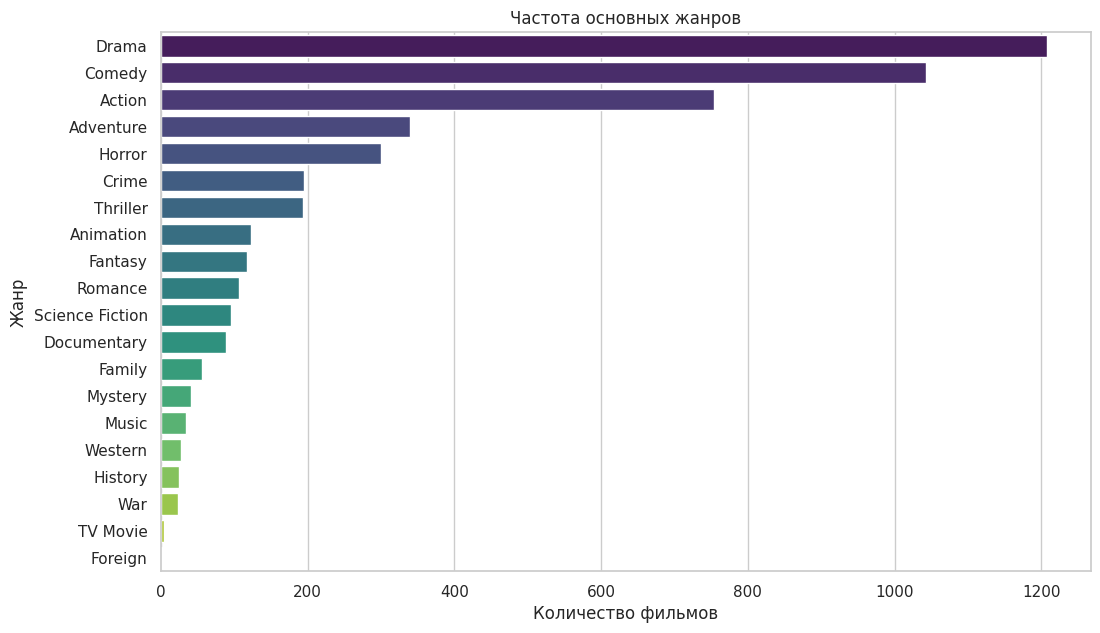

,count
primary_genre,
Drama,1207
Comedy,1042
Action,754
Adventure,339
Horror,300
Crime,195
Thriller,194
Animation,123
Fantasy,117


In [ ]:
# Ваш код здесь
genre_counts = (
    df_clean["primary_genre"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))
sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index,
    hue=genre_counts.index,
    legend=False,
    palette="viridis"
)
plt.title("Частота основных жанров")
plt.xlabel("Количество фильмов")
plt.ylabel("Жанр")
plt.show()

display(genre_counts)

**Вывод:**

Анализ частоты основных жанров показал, что в датасете преобладают драмы: к жанру Drama относятся 1 207 фильмов, что составляет около 25,1% выборки. Далее следуют комедии — 1 042 фильма (21,7%) и боевики — 754 фильма (15,7%). Совокупно эти три жанра формируют примерно 62,5% всех наблюдений. Это необходимо учитывать при дальнейшей интерпретации результатов, поскольку общие средние показатели датасета в значительной степени определяются фильмами жанров Drama, Comedy и Action. Жанры TV Movie, Foreign, War, History и Western представлены небольшим числом наблюдений, поэтому выводы об их среднем бюджете, сборах или рейтинге будут менее устойчивыми и могут сильно зависеть от отдельных фильмов.

### Вопрос 2. Какие жанры приносят наибольшие средние сборы?

Рассчитайте средний ``revenue`` по жанрам (через ``.groupby()`` + ``.mean()``) и визуализируйте результат.

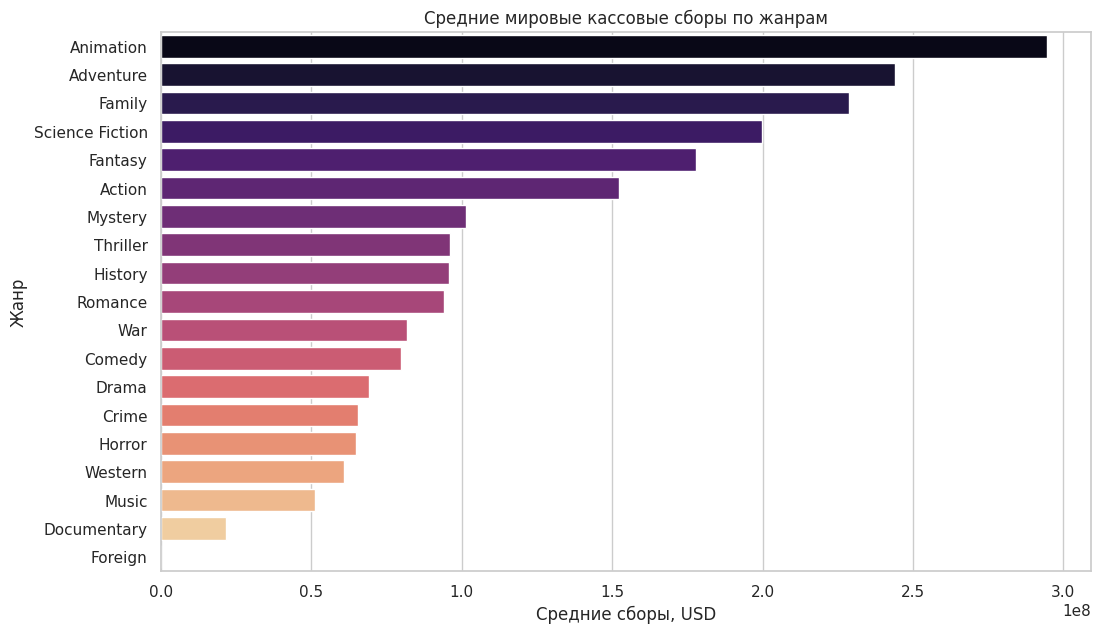

,primary_genre,revenue
2,Animation,2.944274e+08
1,Adventure,2.440813e+08
7,Family,2.289083e+08
15,Science Fiction,1.997302e+08
8,Fantasy,1.779838e+08
0,Action,1.521250e+08
13,Mystery,1.014581e+08
17,Thriller,9.617794e+07
10,History,9.575792e+07
14,Romance,9.418331e+07


In [ ]:
# Ваш код здесь
genre_revenue = (
    df_clean
    .groupby("primary_genre", as_index=False)["revenue"]
    .mean()
    .dropna()
    .sort_values("revenue", ascending=False)
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=genre_revenue,
    x="revenue",
    y="primary_genre",
    hue="primary_genre",
    legend=False,
    palette="magma"
)
plt.title("Средние мировые кассовые сборы по жанрам")
plt.xlabel("Средние сборы, USD")
plt.ylabel("Жанр")
plt.show()

display(genre_revenue)

**Вывод:**

Анализ средних кассовых сборов показал, что наиболее коммерчески успешными по среднему значению являются анимационные фильмы: их средние мировые сборы составляют около 294,4 млн USD. На втором месте находятся приключенческие фильмы со средними сборами 244,1 млн USD, на третьем — семейные фильмы с показателем 228,9 млн USD. Высокие средние сборы также характерны для жанров Science Fiction, Fantasy и Action.

Полученный результат указывает, что фильмы, ориентированные на широкую аудиторию, семейный просмотр, визуальные эффекты и международный прокат, имеют высокий кассовый потенциал. Однако вывод нельзя трактовать как гарантию успеха конкретного проекта: распределение сборов сильно скошено, а средние значения могут быть повышены несколькими блокбастерами. Поэтому при выборе жанра для нового фильма необходимо анализировать не только средние сборы, но и медиану, бюджет, прибыль, ROI, размер жанровой выборки и риск кассового провала.

### Вопрос 3. Как менялись сборы и бюджеты по годам?

Сгруппируйте данные по ``release_year`` через ``.groupby()`` + ``.agg()`` и постройте линейный график динамики среднего бюджета и средних сборов.

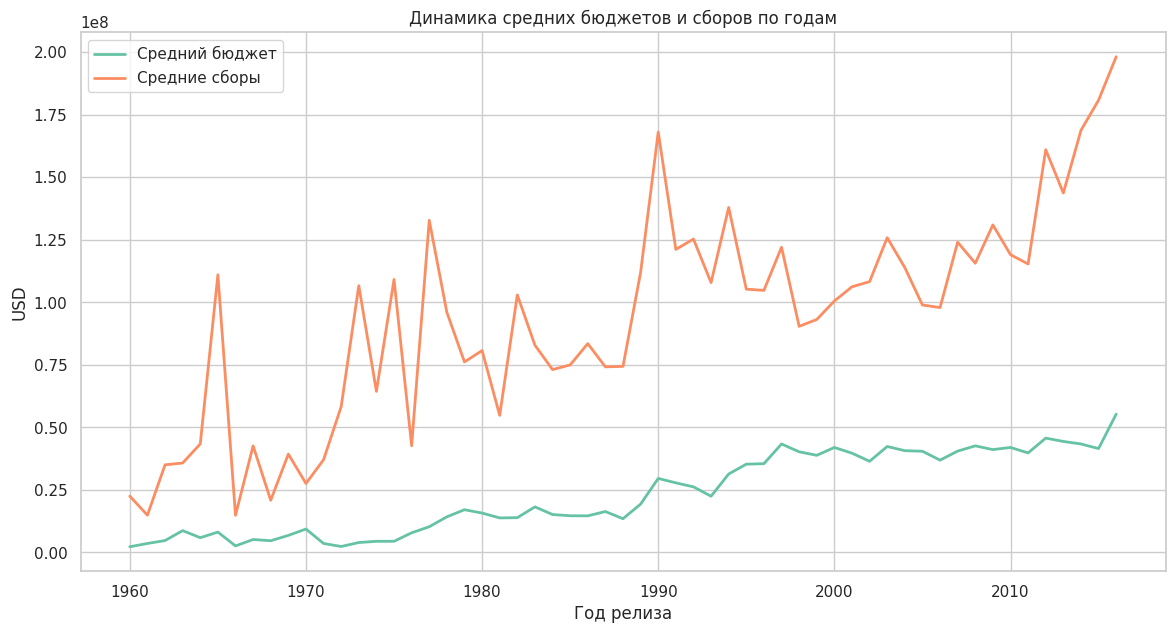

,release_year,avg_budget,avg_revenue,movies
75,2003.0,4.233284e+07,1.257816e+08,169
76,2004.0,4.066328e+07,1.138370e+08,204
77,2005.0,4.043684e+07,9.888470e+07,217
78,2006.0,3.688072e+07,9.785819e+07,237
79,2007.0,4.049086e+07,1.239972e+08,195
80,2008.0,4.258898e+07,1.155827e+08,227
81,2009.0,4.109928e+07,1.308860e+08,247
82,2010.0,4.195388e+07,1.189975e+08,225
83,2011.0,3.976527e+07,1.152636e+08,223
84,2012.0,4.568417e+07,1.609447e+08,208


In [ ]:
# Ваш код здесь
yearly = (
    df_clean
    .groupby("release_year", as_index=False)
    .agg(
        avg_budget=("budget", "mean"),
        avg_revenue=("revenue", "mean"),
        movies=("title", "count")
    )
    .query("release_year >= 1960")
)

plt.figure(figsize=(14, 7))
plt.plot(
    yearly["release_year"],
    yearly["avg_budget"],
    label="Средний бюджет",
    linewidth=2
)
plt.plot(
    yearly["release_year"],
    yearly["avg_revenue"],
    label="Средние сборы",
    linewidth=2
)

plt.title("Динамика средних бюджетов и сборов по годам")
plt.xlabel("Год релиза")
plt.ylabel("USD")
plt.legend()
plt.show()

display(yearly.tail(15))

**Вывод:**

Анализ динамики средних бюджетов и кассовых сборов за 2003–2016 годы показал общий рост номинальных финансовых показателей киноиндустрии. Средний бюджет фильмов в большинстве лет находился в диапазоне от 37 до 46 млн USD, однако в 2016 году вырос до 55,3 млн USD. Средние кассовые сборы менялись сильнее: после снижения примерно до 98 млн USD в 2005–2006 годах они увеличились до 180,8 млн USD в 2015 году и до 198,1 млн USD в 2016 году.

Таким образом, в конце рассматриваемого периода фильмы в среднем становились дороже и собирали больше. При этом рост сборов происходил неравномерно, поэтому высокий бюджет нельзя считать гарантией коммерческого успеха. Для корректной интерпретации необходимо учитывать влияние инфляции, жанра, маркетинговых расходов, франшизности проекта и неполноту финансовых данных. 2017 год исключается из анализа, поскольку в нём представлен только один фильм без данных о бюджете и сборах.

### Вопрос 4. Какие фильмы имеют наибольший ROI (окупаемость)?

Найдите топ-10 фильмов с наибольшим ROI (через `.sort_values()`). Какой жанр преобладает?

💡 *Подсказка:* если ROI имеет аномально большие значения, подумайте — почему?

,title,primary_genre,budget,revenue,profit,roi
3813,Gone with the Wind,Drama,"$4,000,000","$400,176,459","$396,176,459","9,904.41%"
4661,The Big Parade,Drama,"$245,000","$22,000,000","$21,755,000","8,879.59%"
4291,Saw,Horror,"$1,200,000","$103,911,669","$102,711,669","8,559.31%"
4595,The Evil Dead,Horror,"$350,000","$29,400,000","$29,050,000","8,300.00%"
2967,E.T. the Extra-Terrestrial,Science Fiction,"$10,500,000","$792,910,554","$782,410,554","7,451.53%"
3593,My Big Fat Greek Wedding,Comedy,"$5,000,000","$368,744,044","$363,744,044","7,274.88%"
3824,The Full Monty,Comedy,"$3,500,000","$257,850,122","$254,350,122","7,267.15%"
4672,A Fistful of Dollars,Western,"$200,000","$14,500,000","$14,300,000","7,150.00%"
2912,Star Wars,Adventure,"$11,000,000","$775,398,007","$764,398,007","6,949.07%"
2809,Jaws,Horror,"$7,000,000","$470,654,000","$463,654,000","6,623.63%"


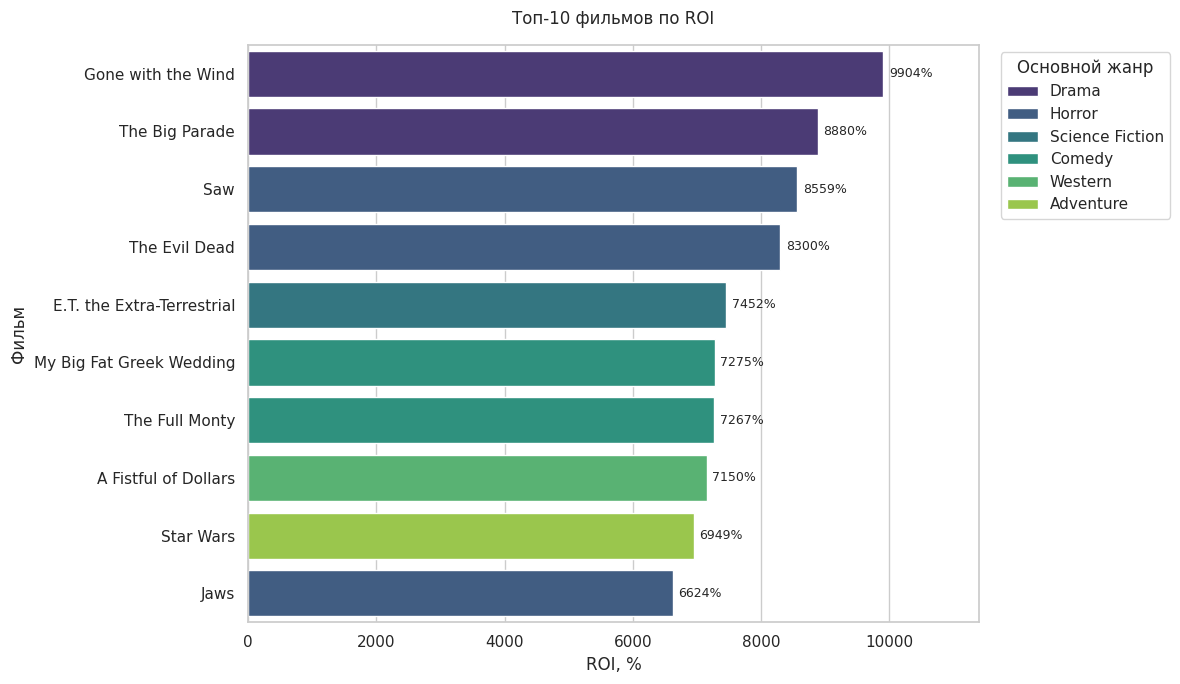

Самый частый жанр в топ-10 ROI:
Horror


In [ ]:
# Ваш код здесь
# Отбираем фильмы с известными бюджетом и сборами
roi_df = (
    df_clean
    .dropna(subset=["budget", "revenue", "roi"])
    .query("budget > 0 and revenue > 0")
    .copy()
)

# Убираем экстремальные значения ROI:
# они обычно возникают у фильмов с очень маленьким бюджетом
roi_df_plot = (
    roi_df
    .loc[roi_df["roi"].between(-10_000, 10_000)]
    .sort_values("roi", ascending=False)
)

# Топ-10 фильмов по ROI после фильтрации аномалий
top_roi = roi_df_plot[
    ["title", "primary_genre", "budget", "revenue", "profit", "roi"]
].head(10).copy()

display(
    top_roi.style.format({
        "budget": "${:,.0f}",
        "revenue": "${:,.0f}",
        "profit": "${:,.0f}",
        "roi": "{:,.2f}%"
    })
)

# Создаём статичную фигуру
fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    data=top_roi,
    x="roi",
    y="title",
    hue="primary_genre",
    dodge=False,
    palette="viridis",
    ax=ax
)

ax.set_title("Топ-10 фильмов по ROI", pad=15)
ax.set_xlabel("ROI, %")
ax.set_ylabel("Фильм")

# Подписи процентов у столбцов
max_roi = top_roi["roi"].max()

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f%%",
        padding=4,
        fontsize=9
    )

ax.set_xlim(0, max_roi * 1.15)

ax.legend(
    title="Основной жанр",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

fig.tight_layout()
plt.show()

# Закрываем фигуру: полезно, если ячейку выполняют много раз
plt.close(fig)

print("Самый частый жанр в топ-10 ROI:")
print(top_roi["primary_genre"].mode().to_string(index=False))

**Вывод:**
Анализ топ-10 фильмов по ROI показал, что наибольшую окупаемость обеспечивают не обязательно самые дорогие проекты, а фильмы с умеренным или небольшим бюджетом, которые достигают очень высоких кассовых сборов. Максимальный ROI зафиксирован у фильма Gone with the Wind — 9 904,41%: при бюджете 4 млн USD он собрал более 400 млн USD. В топ-10 также вошли Saw, The Evil Dead, E.T. the Extra-Terrestrial, Star Wars и Jaws.

Наиболее распространённым жанром среди десяти наиболее окупаемых фильмов является Horror: он представлен тремя картинами. Это позволяет предположить, что хорроры с контролируемым бюджетом могут быть перспективными с точки зрения окупаемости. Однако данный вывод требует осторожности: показатель ROI не учитывает маркетинговые расходы и долю кинотеатров, а исторические фильмы могут иметь накопленные сборы от повторных прокатов. Поэтому при инвестиционном решении следует оценивать одновременно ROI, абсолютную прибыль, бюджет, риск кассового провала и актуальность жанра для целевой аудитории.

Экстремальный ROI часто возникает у фильмов с очень маленьким указанным бюджетом. Это может отражать реальный успех независимого фильма, но также неполноту данных о бюджете, поэтому для инвестиционных решений желательно использовать фильтр минимального бюджета.

### Вопрос 5. Как распределяются оценки по языку оригинала?

Сравните распределения ``vote_average`` для англоязычных (``original_language == 'en'``) и неанглоязычных фильмов. Постройте гистограммы обеих групп на одном графике.

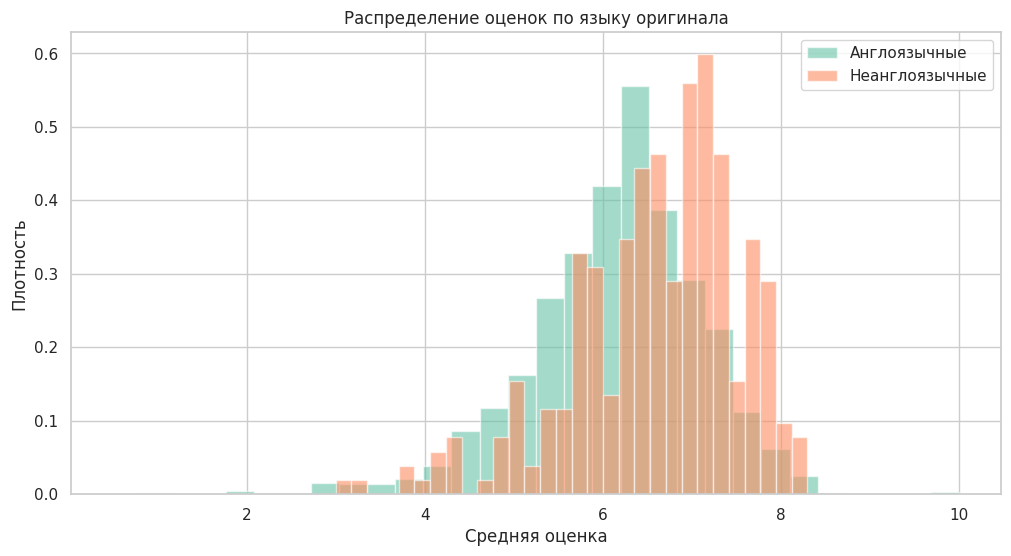

Средняя оценка англоязычных: 6.144794243310097
Средняя оценка неанглоязычных: 6.603412969283276


In [ ]:
# Ваш код здесь
english_votes = df_clean.loc[
    df_clean["original_language"] == "en",
    "vote_average"
].dropna()

non_english_votes = df_clean.loc[
    df_clean["original_language"] != "en",
    "vote_average"
].dropna()

plt.figure(figsize=(12, 6))

plt.hist(
    english_votes,
    bins=30,
    alpha=0.6,
    label="Англоязычные",
    density=True
)

plt.hist(
    non_english_votes,
    bins=30,
    alpha=0.6,
    label="Неанглоязычные",
    density=True
)

plt.title("Распределение оценок по языку оригинала")
plt.xlabel("Средняя оценка")
plt.ylabel("Плотность")
plt.legend()
plt.show()

print("Средняя оценка англоязычных:", english_votes.mean())
print("Средняя оценка неанглоязычных:", non_english_votes.mean())

**Вывод:**

Средняя оценка англоязычных фильмов составляет 6,14 балла, а неанглоязычных — 6,60 балла. Следовательно, неанглоязычные фильмы в исследуемой выборке имеют среднюю оценку выше на 0,46 балла. Полученный результат может указывать на различия в предпочтениях аудитории, жанровом составе фильмов, особенностях выборки или на то, что неанглоязычные фильмы чаще представлены более отобранными и заметными проектами.

При этом разница в 0,46 балла сама по себе не доказывает статистическую значимость. Для окончательного вывода необходимо провести двухвыборочный t-тест и рассчитать размер эффекта Cohen’s d. Если p-value окажется меньше уровня значимости 0,05, гипотеза о равенстве средних оценок будет отвергнута. Cohen’s d позволит определить, является ли обнаруженное различие практически важным: ориентировочно
𝑑
≈
0.2
d≈0.2 считают малым эффектом,
𝑑
≈
0.5
d≈0.5 — средним, а
𝑑
≥
0.8
d≥0.8 — крупным.


### Вопрос 6. Как длительность фильма связана с оценкой?

Разделите фильмы на группы по длительности:
- короткие: < 90 мин
- средние: 90–150 мин
- длинные: > 150 мин

Сравните средние оценки в каждой группе.

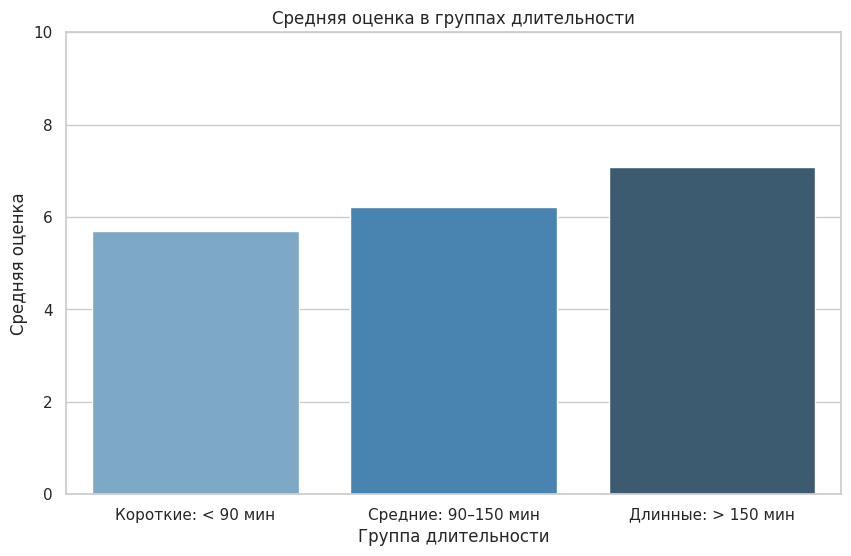

,runtime_group,vote_average
1,Короткие: < 90 мин,5.693702
2,Средние: 90–150 мин,6.213065
0,Длинные: > 150 мин,7.088824


In [ ]:
# Ваш код здесь
def runtime_group(runtime):
    if runtime < 90:
        return "Короткие: < 90 мин"
    elif runtime <= 150:
        return "Средние: 90–150 мин"
    return "Длинные: > 150 мин"

df_clean["runtime_group"] = df_clean["runtime"].apply(runtime_group)

runtime_rating = (
    df_clean
    .groupby("runtime_group", as_index=False)["vote_average"]
    .mean()
)

order = [
    "Короткие: < 90 мин",
    "Средние: 90–150 мин",
    "Длинные: > 150 мин"
]

runtime_rating["runtime_group"] = pd.Categorical(
    runtime_rating["runtime_group"],
    categories=order,
    ordered=True
)

runtime_rating = runtime_rating.sort_values("runtime_group")

plt.figure(figsize=(10, 6))
sns.barplot(
    data=runtime_rating,
    x="runtime_group",
    y="vote_average",
    hue="runtime_group",
    legend=False,
    palette="Blues_d"
)
plt.title("Средняя оценка в группах длительности")
plt.xlabel("Группа длительности")
plt.ylabel("Средняя оценка")
plt.ylim(0, 10)
plt.show()

display(runtime_rating)

**Вывод:**
Анализ оценок в группах длительности показал положительную связь между продолжительностью фильма и средней оценкой зрителей. Короткие фильмы продолжительностью менее 90 минут имеют среднюю оценку 5,69 балла. Фильмы средней длительности от 90 до 150 минут получают в среднем 6,21 балла, а длинные фильмы продолжительностью более 150 минут — 7,09 балла. Таким образом, средняя оценка длинных фильмов выше оценки коротких фильмов на 1,40 балла.

Полученный результат позволяет предположить, что более продолжительные фильмы в данной выборке воспринимаются зрителями лучше. При этом длительность не следует считать причиной высокой оценки: длинные фильмы могут отличаться от коротких жанром, бюджетом, масштабом производства, популярностью или целевой аудиторией. Для подтверждения статистической значимости различий необходимо провести однофакторный дисперсионный анализ ANOVA либо попарные t-тесты между группами длительности.

---
# **Часть 2. Корреляционный анализ**
---

## **7. Корреляционная матрица**

Постройте корреляционную матрицу для числовых признаков:
``budget``, ``revenue``, ``vote_average``, ``vote_count``, ``runtime``, ``popularity``.

- Рассчитайте коэффициент корреляции, обоснуйте выбор подхода
- Визуализируйте через ``sns.heatmap()`` с аннотациями (``annot=True``)
- Какие пары признаков имеют **сильную** корреляцию (|r| > 0.7)?
- Какие признаки сильнее всего коррелируют с ``revenue``?


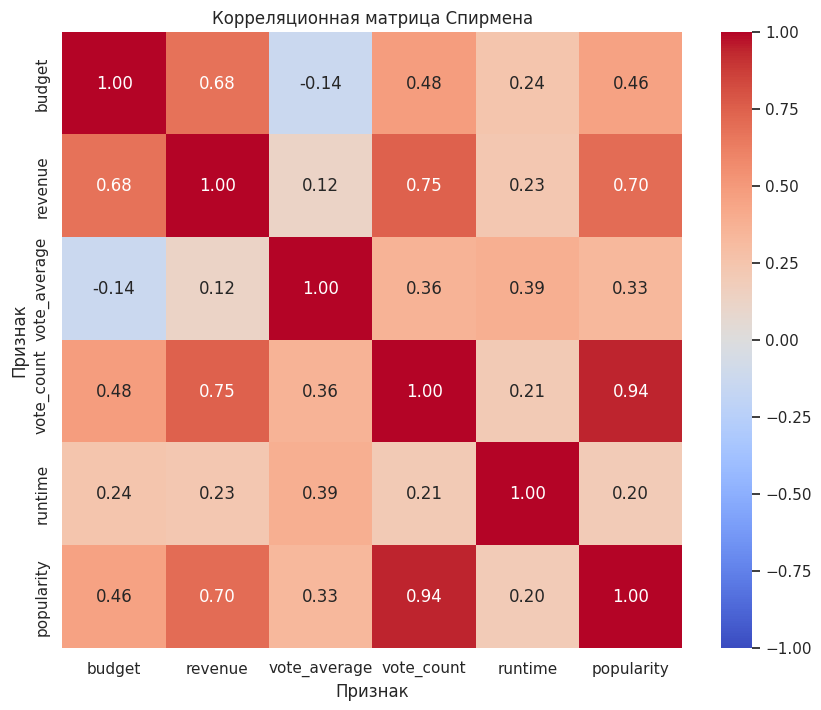

Сильные связи |r| > 0.7:


,feature_1,feature_2,correlation
13,vote_count,popularity,0.939271
6,revenue,vote_count,0.747142
8,revenue,popularity,0.702895


Связи с revenue:


,revenue
revenue,1.000000
vote_count,0.747142
popularity,0.702895
budget,0.678060
runtime,0.229719
vote_average,0.124264


In [ ]:
# Ваш код здесь:
corr_cols = [
    "budget",
    "revenue",
    "vote_average",
    "vote_count",
    "runtime",
    "popularity"
]

corr_df = df_analysis[corr_cols].dropna()

pearson_corr = corr_df.corr(method="pearson")
spearman_corr = corr_df.corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)
plt.title("Корреляционная матрица Спирмена")
plt.xlabel("Признак")
plt.ylabel("Признак")
plt.show()

# Сильные корреляции |r| > 0.7
pairs = (
    spearman_corr.where(
        np.triu(np.ones(spearman_corr.shape), k=1).astype(bool)
    )
    .stack()
    .reset_index()
)

pairs.columns = ["feature_1", "feature_2", "correlation"]
strong_pairs = pairs.loc[
    pairs["correlation"].abs() > 0.7
].sort_values("correlation", key=lambda x: x.abs(), ascending=False)

print("Сильные связи |r| > 0.7:")
display(strong_pairs)

print("Связи с revenue:")
display(
    spearman_corr["revenue"]
    .sort_values(ascending=False)
)

**Интерпретация корреляционной матрицы:**

Корреляционный анализ Спирмена показал, что наиболее сильная связь в датасете наблюдается между количеством пользовательских голосов и популярностью фильма:
r=0.939. Это означает, что популярные фильмы, как правило, получают больше оценок от зрителей.
Кассовые сборы сильнее всего связаны с количеством голосов (r=0.747) и популярностью (r=0.703). Также наблюдается достаточно высокая положительная связь между бюджетом и сборами (r=0.678): более дорогие фильмы в среднем собирают больше, однако эта зависимость не является гарантией коммерческого успеха.
Средняя зрительская оценка практически не связана с кассовыми сборами (r=0.124), а длительность фильма имеет только слабую положительную связь со сборами (r=0.230). Следовательно, высокий рейтинг фильма и большая длительность сами по себе не являются надёжными индикаторами высоких кассовых результатов. При планировании релиза студии следует уделять особое внимание факторам, связанным с охватом аудитории и популярностью проекта.

При этом корреляция показывает статистическую связь, но не доказывает причинность: популярность, количество голосов и сборы могут взаимно усиливать друг друга либо зависеть от общих факторов — масштаба рекламной кампании, широты проката, известности франшизы и состава аудитории.

## **8. Визуализация парных связей**

Постройте scatter-графики (диаграммы рассеяния) для ключевых пар:

1. ``budget`` vs ``revenue`` — как бюджет связан со сборами?
2. ``vote_average`` vs ``revenue`` — высокий рейтинг гарантирует сборы?
3. ``vote_count`` vs ``revenue`` — что сильнее связано со сборами: рейтинг или количество голосов?

Для каждого графика добавьте заголовок и подписи осей.

💡 Инструменты: ``plt.scatter()``, ``sns.scatterplot()``, ``plt.xlabel()``, ``plt.ylabel()``, ``plt.title()``

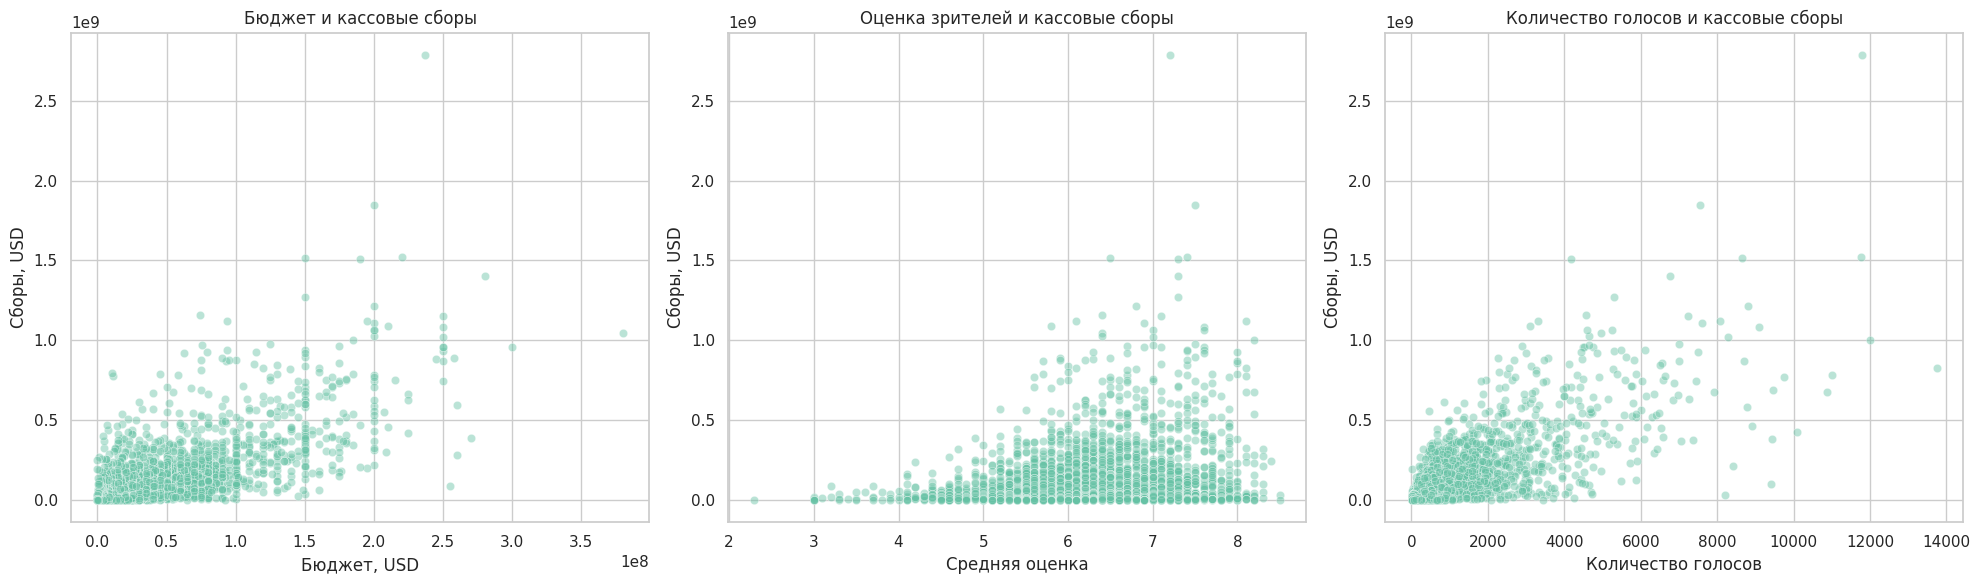

In [ ]:
# Ваш код здесь:
plot_df = df_analysis[
    ["budget", "revenue", "vote_average", "vote_count"]
].dropna()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.scatterplot(
    data=plot_df,
    x="budget",
    y="revenue",
    alpha=0.45,
    ax=axes[0]
)
axes[0].set_title("Бюджет и кассовые сборы")
axes[0].set_xlabel("Бюджет, USD")
axes[0].set_ylabel("Сборы, USD")

sns.scatterplot(
    data=plot_df,
    x="vote_average",
    y="revenue",
    alpha=0.45,
    ax=axes[1]
)
axes[1].set_title("Оценка зрителей и кассовые сборы")
axes[1].set_xlabel("Средняя оценка")
axes[1].set_ylabel("Сборы, USD")

sns.scatterplot(
    data=plot_df,
    x="vote_count",
    y="revenue",
    alpha=0.45,
    ax=axes[2]
)
axes[2].set_title("Количество голосов и кассовые сборы")
axes[2].set_xlabel("Количество голосов")
axes[2].set_ylabel("Сборы, USD")

plt.tight_layout()
plt.show()

**Какие связи вы наблюдаете? Линейные ли они? Есть ли выбросы?**

Связи:
- budget vs revenue: Линейная связь прослеживается в основной массе точек, но график испещрен вертикальным «лесом» дешевых фильмов с непредсказуемыми сборами.
- vote_average vs revenue: Точки образуют широкое облако. Есть дорогие провалы с высоким рейтингом (например, Blade Runner 2049) и дешевые хиты с низким (некоторые комедии студии Happy Madison).
-vote_count vs revenue: Наиболее плотное облако вдоль оси X. Количество голосов — отличный прокси-индикатор охвата аудитории.

В данных выбросы — очень дорогие блокбастеры, рекордные сборы и фильмы с необычно высокой окупаемостью.

---
# **Часть 3. Проверка статистических гипотез**
---

## **9. Доверительный интервал для средней оценки**

Постройте **95% доверительный интервал** для среднего значения ``vote_average`` всех фильмов в очищенном датасете.

**Шаги:**
1. Рассчитайте выборочное среднее и стандартное отклонение (``.std(ddof=1)``)
2. Рассчитайте стандартную ошибку среднего
3. Найдите критическое значение t-распределения через ``stats.t.ppf()``
4. Вычислите погрешность и границы интервала
5. Проверьте результат через ``stats.t.interval()``

**Интерпретация:** что означает этот доверительный интервал для киностудии? Какую среднюю оценку можно ожидать от фильма?

In [ ]:
# Ваш код здесь: ала
ratings = df_analysis["vote_average"].dropna()

n = ratings.shape[0]
mean_rating = ratings.mean()
std_rating = ratings.std(ddof=1)

standard_error = std_rating / np.sqrt(n)
t_critical = stats.t.ppf(0.975, df=n - 1)

margin_error = t_critical * standard_error
ci_lower = mean_rating - margin_error
ci_upper = mean_rating + margin_error

print(f"n = {n}")
print(f"Средняя оценка = {mean_rating:.3f}")
print(f"Стандартное отклонение = {std_rating:.3f}")
print(f"Стандартная ошибка = {standard_error:.4f}")
print(f"Критическое t = {t_critical:.4f}")
print(f"95% ДИ вручную: [{ci_lower:.3f}; {ci_upper:.3f}]")

ci_check = stats.t.interval(
    confidence=0.95,
    df=n - 1,
    loc=mean_rating,
    scale=standard_error
)

print(f"95% ДИ через stats.t.interval(): [{ci_check[0]:.3f}; {ci_check[1]:.3f}]")

n = 3227
Средняя оценка = 6.313
Стандартное отклонение = 0.860
Стандартная ошибка = 0.0151
Критическое t = 1.9607
95% ДИ вручную: [6.284; 6.343]
95% ДИ через stats.t.interval(): [6.284; 6.343]


**Интерпретация доверительного интервала:**
Для очищенной выборки из 3 227 фильмов средняя зрительская оценка составила 6,313 балла при стандартном отклонении 0,860. Построенный 95% доверительный интервал для средней оценки равен [6.284;6.343]. Результат, полученный вручную, совпал с результатом функции stats.t.interval(), что подтверждает корректность вычислений.

Интервал является узким, поскольку выборка имеет большой объём, а стандартная ошибка среднего составляет всего 0,0151. Следовательно, средняя оценка фильмов в рассматриваемой очищенной выборке оценивается достаточно точно и находится примерно на уровне 6,3 балла из 10. Данный интервал характеризует среднюю оценку всей выборки, а не диапазон оценок отдельных фильмов.

## **10. Гипотезы**

> ✏️ Для получения зачёта выберите как **минимум одну** гипотезу на выбор из двух, представленных в разделе 10.

### **Гипотеза 1. Отличаются ли оценки англоязычных и неанглоязычных фильмов?**

Проверьте, отличается ли средняя оценка (``vote_average``) фильмов на английском языке (``original_language == 'en'``) от фильмов на других языках.

**Шаги:**
1. Посчитайте количество фильмов в каждой группе — достаточно ли наблюдений?
2. Постройте гистограммы обеих групп на одном графике (с ``alpha``)
3. Сформулируйте H₀ и H₁
4. Проведите двухвыборочный тест
5. Рассчитайте размер эффекта (Cohen's d) с помощью ``np.sqrt()``
6. Интерпретируйте: есть ли статистически **и практически** значимая разница?

💡 **Формула Cohen's d:**

d = (x̄₁ − x̄₂) / s_pooled,  где  s_pooled = √((s₁² + s₂²) / 2)

Размер англоязычной группы: 3100
Размер неанглоязычной группы: 127


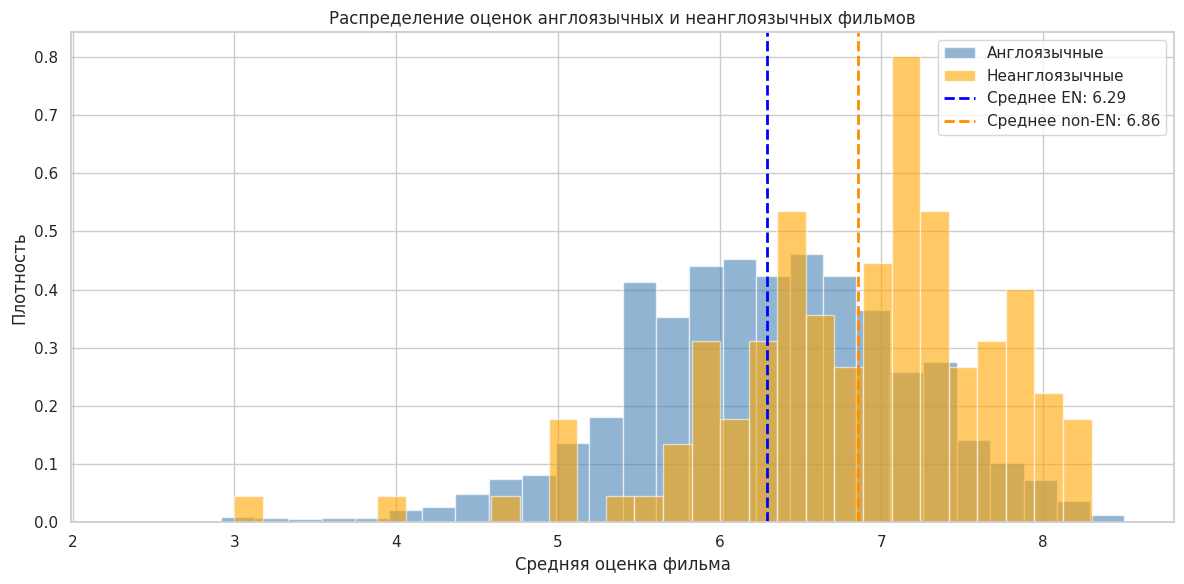


Средняя оценка англоязычных: 6.291
Средняя оценка неанглоязычных: 6.855
Разница средних: -0.564
t-статистика: -7.1566
p-value: 0.000000
Cohen's d: -0.6545

Вывод t-теста: отвергаем H₀.
Средние оценки англоязычных и неанглоязычных фильмов статистически значимо различаются.
Размер эффекта Cohen's d: средний (|d| = 0.654).


In [ ]:
# Ваш код здесь:
# Оценки англоязычных фильмов
en = df_analysis.loc[
    df_analysis["original_language"] == "en",
    "vote_average"
].dropna()

# Оценки неанглоязычных фильмов
non_en = df_analysis.loc[
    df_analysis["original_language"] != "en",
    "vote_average"
].dropna()

# Размеры групп
print(f"Размер англоязычной группы: {len(en)}")
print(f"Размер неанглоязычной группы: {len(non_en)}")

# Гистограмма распределений
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(
    en,
    bins=30,
    alpha=0.6,
    density=True,
    label="Англоязычные",
    color="steelblue"
)

ax.hist(
    non_en,
    bins=30,
    alpha=0.6,
    density=True,
    label="Неанглоязычные",
    color="orange"
)

# Линии средних значений
ax.axvline(
    en.mean(),
    color="blue",
    linestyle="--",
    linewidth=2,
    label=f"Среднее EN: {en.mean():.2f}"
)

ax.axvline(
    non_en.mean(),
    color="darkorange",
    linestyle="--",
    linewidth=2,
    label=f"Среднее non-EN: {non_en.mean():.2f}"
)

ax.set_title("Распределение оценок англоязычных и неанглоязычных фильмов")
ax.set_xlabel("Средняя оценка фильма")
ax.set_ylabel("Плотность")
ax.legend()

plt.tight_layout()
plt.show()

# Welch t-test:
# не предполагает равенства дисперсий групп
t_stat, p_value = stats.ttest_ind(
    en,
    non_en,
    equal_var=False
)

# Cohen's d
pooled_std = np.sqrt(
    (en.var(ddof=1) + non_en.var(ddof=1)) / 2
)

cohens_d = (
    (en.mean() - non_en.mean())
    / pooled_std
)

# Результаты
print(f"\nСредняя оценка англоязычных: {en.mean():.3f}")
print(f"Средняя оценка неанглоязычных: {non_en.mean():.3f}")
print(f"Разница средних: {en.mean() - non_en.mean():.3f}")
print(f"t-статистика: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Cohen's d: {cohens_d:.4f}")

# Автоматический статистический вывод
alpha = 0.05

if p_value < alpha:
    print("\nВывод t-теста: отвергаем H₀.")
    print("Средние оценки англоязычных и неанглоязычных фильмов статистически значимо различаются.")
else:
    print("\nВывод t-теста: нет оснований отвергнуть H₀.")
    print("Статистически значимых различий средних оценок не обнаружено.")

# Интерпретация размера эффекта
abs_d = abs(cohens_d)

if abs_d < 0.2:
    effect_text = "пренебрежимо малый"
elif abs_d < 0.5:
    effect_text = "малый"
elif abs_d < 0.8:
    effect_text = "средний"
else:
    effect_text = "большой"

print(f"Размер эффекта Cohen's d: {effect_text} (|d| = {abs_d:.3f}).")

**Интерпретация:**

H₀: средняя оценка англоязычных и неанглоязычных фильмов одинакова.

H₁: средние оценки англоязычных и неанглоязычных фильмов различаются.

Средняя оценка англоязычных фильмов составила 6,291 балла, а неанглоязычных — 6,855 балла. Разница средних равна −0,564 балла при расчёте «англоязычные минус неанглоязычные», то есть неанглоязычные фильмы в среднем получают оценку выше на 0,564 балла.

Двухвыборочный Welch t-test показал статистически значимое различие между группами: t=−7.1566, p<0.001. При уровне значимости α=0.05 нулевая гипотеза отвергается.

Cohen’s d=−0.6545, а абсолютная величина эффекта равна 0,6545. Это соответствует среднему размеру эффекта. Таким образом, различие оценок является не только статистически значимым, но и практически заметным.

При этом результат не означает, что язык оригинала сам по себе повышает или снижает рейтинг. Различие может быть связано с жанровым составом, страной производства, годом релиза, особенностями аудитории, размером выборки и правилами попадания фильмов в датасет. Это наблюдательный анализ, поэтому он показывает связь, но не доказывает причинность.

### **Гипотеза 2. Дорогие и дешёвые фильмы — одинаковый ли ROI?**

Разделите фильмы на две группы по **медиане бюджета**:
- «Дорогие» — бюджет строго выше медианы
- «Дешёвые» — бюджет меньше или равен медиане

Проверьте, отличается ли средний ``roi`` между этими группами.

💡 *Подсказка:* если в данных есть экстремальные значения ROI, можно отфильтровать фильмы с ``|roi| > 10000%`` — это аномалии (фильмы с микробюджетом), которые искажают анализ.

**Шаги:**
1. Рассчитайте медиану бюджета
2. Создайте два подмножества
3. Сформулируйте H₀ и H₁
4. Проведите двухвыборочный тест
5. Рассчитайте Cohen's d
6. Интерпретируйте: стоит ли делать дорогие фильмы с точки зрения окупаемости?

H₀: средний ROI дорогих и дешёвых фильмов одинаков.
H₁: средний ROI дорогих и дешёвых фильмов различается.

Медианный бюджет: $25,515,000
Количество дешёвых фильмов: 1602
Количество дорогих фильмов: 1602

Дешёвые фильмы:
Средний ROI: 472.62%
Медианный ROI: 157.00%
Стандартное отклонение ROI: 1015.97%

Дорогие фильмы:
Средний ROI: 170.16%
Медианный ROI: 115.42%
Стандартное отклонение ROI: 235.79%


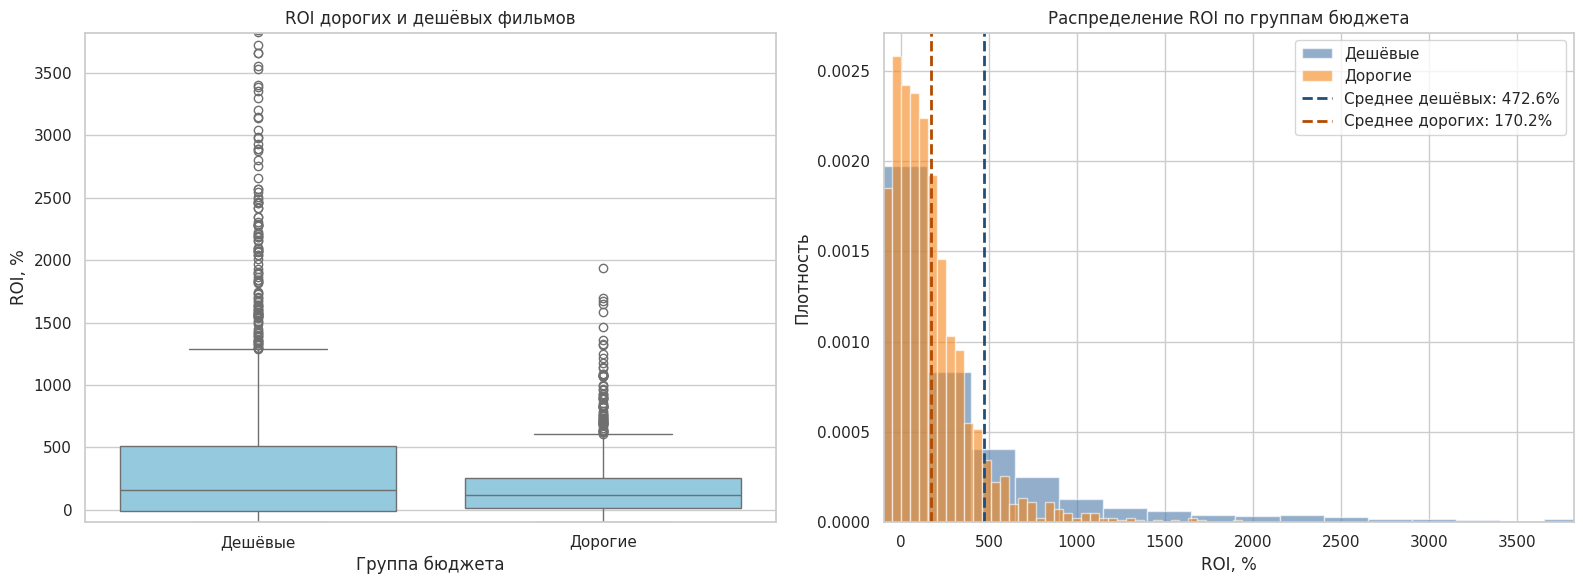


РЕЗУЛЬТАТЫ ПРОВЕРКИ ГИПОТЕЗЫ
Разница средних ROI (дорогие − дешёвые): -302.46%
t-статистика: -11.6072
p-value: 0.000000
Cohen's d: -0.4101

Статистический вывод: отвергаем H₀.
Средний ROI дорогих и дешёвых фильмов статистически значимо различается.
Размер эффекта Cohen's d: малый (|d| = 0.410).

Рекомендация для киностудии:
Дешёвые фильмы показывают статистически более высокий средний ROI в этой выборке. Это поддерживает стратегию контролируемого бюджета, но не означает, что нужно полностью отказаться от дорогих проектов: они могут создавать большую абсолютную прибыль и франшизную ценность.


In [ ]:
# Ваш код здесь:
# ============================================================
# Гипотеза 2. Отличается ли ROI дорогих и дешёвых фильмов?
# ============================================================

# H0: средний ROI дорогих и дешёвых фильмов одинаков.
# H1: средний ROI дорогих и дешёвых фильмов различается.

alpha = 0.05

# ------------------------------------------------------------
# 1. Подготовка данных для анализа ROI
# ------------------------------------------------------------
# Оставляем фильмы с известными положительными бюджетом и сборами.
roi_analysis = (
    df_clean
    .dropna(subset=["budget", "revenue", "roi"])
    .query("budget > 0 and revenue > 0")
    .copy()
)

# Убираем экстремальные ROI:
# они часто возникают из-за очень маленького бюджета
# и могут существенно искажать средние значения.
roi_analysis = roi_analysis[
    roi_analysis["roi"].between(-10_000, 10_000)
].copy()

# ------------------------------------------------------------
# 2. Деление на дорогие и дешёвые фильмы
# ------------------------------------------------------------
median_budget = roi_analysis["budget"].median()

roi_analysis["budget_group"] = np.where(
    roi_analysis["budget"] > median_budget,
    "Дорогие",
    "Дешёвые"
)

cheap_roi = roi_analysis.loc[
    roi_analysis["budget_group"] == "Дешёвые",
    "roi"
].dropna()

expensive_roi = roi_analysis.loc[
    roi_analysis["budget_group"] == "Дорогие",
    "roi"
].dropna()

# ------------------------------------------------------------
# 3. Описательная статистика
# ------------------------------------------------------------
print("H₀: средний ROI дорогих и дешёвых фильмов одинаков.")
print("H₁: средний ROI дорогих и дешёвых фильмов различается.\n")

print(f"Медианный бюджет: ${median_budget:,.0f}")
print(f"Количество дешёвых фильмов: {len(cheap_roi)}")
print(f"Количество дорогих фильмов: {len(expensive_roi)}\n")

print("Дешёвые фильмы:")
print(f"Средний ROI: {cheap_roi.mean():.2f}%")
print(f"Медианный ROI: {cheap_roi.median():.2f}%")
print(f"Стандартное отклонение ROI: {cheap_roi.std(ddof=1):.2f}%\n")

print("Дорогие фильмы:")
print(f"Средний ROI: {expensive_roi.mean():.2f}%")
print(f"Медианный ROI: {expensive_roi.median():.2f}%")
print(f"Стандартное отклонение ROI: {expensive_roi.std(ddof=1):.2f}%")

# ------------------------------------------------------------
# 4. Визуализация распределений ROI
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot: ограничиваем ось Y для читаемости,
# поскольку редкие большие ROI всё ещё могут растягивать масштаб.
sns.boxplot(
    data=roi_analysis,
    x="budget_group",
    y="roi",
    order=["Дешёвые", "Дорогие"],
    color="skyblue",
    ax=axes[0]
)

axes[0].set_title("ROI дорогих и дешёвых фильмов")
axes[0].set_xlabel("Группа бюджета")
axes[0].set_ylabel("ROI, %")

axes[0].set_ylim(
    roi_analysis["roi"].quantile(0.01),
    roi_analysis["roi"].quantile(0.99)
)

# Показываем центральную часть распределения,
# чтобы boxplot был информативным.
axes[0].set_ylim(
    roi_analysis["roi"].quantile(0.01),
    roi_analysis["roi"].quantile(0.99)
)

# Гистограммы распределений
axes[1].hist(
    cheap_roi,
    bins=40,
    alpha=0.6,
    density=True,
    label="Дешёвые",
    color="#4C78A8"
)

axes[1].hist(
    expensive_roi,
    bins=40,
    alpha=0.6,
    density=True,
    label="Дорогие",
    color="#F58518"
)

axes[1].axvline(
    cheap_roi.mean(),
    color="#1F4E79",
    linestyle="--",
    linewidth=2,
    label=f"Среднее дешёвых: {cheap_roi.mean():.1f}%"
)

axes[1].axvline(
    expensive_roi.mean(),
    color="#B34A00",
    linestyle="--",
    linewidth=2,
    label=f"Среднее дорогих: {expensive_roi.mean():.1f}%"
)

axes[1].set_title("Распределение ROI по группам бюджета")
axes[1].set_xlabel("ROI, %")
axes[1].set_ylabel("Плотность")
axes[1].set_xlim(
    roi_analysis["roi"].quantile(0.01),
    roi_analysis["roi"].quantile(0.99)
)
axes[1].legend()

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Welch t-test
# ------------------------------------------------------------
# equal_var=False — t-тест Уэлча:
# не предполагает равенства дисперсий в двух группах.
t_stat, p_value = stats.ttest_ind(
    expensive_roi,
    cheap_roi,
    equal_var=False,
    alternative="two-sided"
)

# ------------------------------------------------------------
# 6. Cohen's d
# ------------------------------------------------------------
# Используем объединённое стандартное отклонение.
pooled_std = np.sqrt(
    (
        expensive_roi.var(ddof=1)
        + cheap_roi.var(ddof=1)
    ) / 2
)

cohens_d = (
    (expensive_roi.mean() - cheap_roi.mean())
    / pooled_std
)

# ------------------------------------------------------------
# 7. Результаты теста
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("РЕЗУЛЬТАТЫ ПРОВЕРКИ ГИПОТЕЗЫ")
print("=" * 60)

print(f"Разница средних ROI (дорогие − дешёвые): "
      f"{expensive_roi.mean() - cheap_roi.mean():.2f}%")

print(f"t-статистика: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Cohen's d: {cohens_d:.4f}")

# Интерпретация p-value
if p_value < alpha:
    print("\nСтатистический вывод: отвергаем H₀.")
    print("Средний ROI дорогих и дешёвых фильмов статистически значимо различается.")
else:
    print("\nСтатистический вывод: нет оснований отвергнуть H₀.")
    print("Статистически значимое различие среднего ROI не обнаружено.")

# Интерпретация Cohen's d
abs_d = abs(cohens_d)

if abs_d < 0.2:
    effect_size = "пренебрежимо малый"
elif abs_d < 0.5:
    effect_size = "малый"
elif abs_d < 0.8:
    effect_size = "средний"
else:
    effect_size = "большой"

print(f"Размер эффекта Cohen's d: {effect_size} (|d| = {abs_d:.3f}).")

# Рекомендация в зависимости от направления эффекта
if p_value < alpha and expensive_roi.mean() > cheap_roi.mean():
    print("\nРекомендация для киностудии:")
    print(
        "Дорогие фильмы показывают статистически более высокий средний ROI "
        "в этой выборке. Однако решение о крупном бюджете следует принимать "
        "вместе с анализом абсолютной прибыли, риска убытка, жанра и стратегии релиза."
    )

elif p_value < alpha and expensive_roi.mean() < cheap_roi.mean():
    print("\nРекомендация для киностудии:")
    print(
        "Дешёвые фильмы показывают статистически более высокий средний ROI "
        "в этой выборке. Это поддерживает стратегию контролируемого бюджета, "
        "но не означает, что нужно полностью отказаться от дорогих проектов: "
        "они могут создавать большую абсолютную прибыль и франшизную ценность."
    )

else:
    print("\nРекомендация для киностудии:")
    print(
        "По ROI не выявлено статистически значимого преимущества дорогих "
        "или дешёвых фильмов. Бюджет следует выбирать с учётом жанра, "
        "потенциальной аудитории, ожидаемой прибыли и уровня риска."
    )

**Интерпретация:**

H₀: средний ROI дорогих и дешёвых фильмов одинаков.

H₁: средний ROI дорогих и дешёвых фильмов различается.

Для проверки гипотезы фильмы были разделены по медианному бюджету 25,515 млн USD на две равные группы: дешёвые фильмы с бюджетом не выше медианы и дорогие фильмы с бюджетом выше медианы. В каждой группе оказалось по 1 602 фильма.

Средний ROI дешёвых фильмов составил 472,62%, тогда как у дорогих фильмов он равен 170,16%. Разница средних составила −302,46 процентного пункта при расчёте «дорогие минус дешёвые», то есть дешёвые фильмы в среднем имеют более высокую окупаемость. Медианный ROI также выше у дешёвых проектов: 157,00% против 115,42% у дорогих

Welch t-test показал статистически значимое различие между группами:
t=−11.6072, p<0.001. При уровне значимости 0,05 нулевая гипотеза о равенстве среднего ROI отвергается. Размер эффекта Cohen’s d=−0.4101, что соответствует малому, но практически заметному эффекту.

Таким образом, недорогие фильмы в рассматриваемой выборке имеют преимущество по относительной окупаемости. Однако их ROI значительно более изменчив: стандартное отклонение составляет 1 015,97% против 235,79% у дорогих фильмов. Поэтому киностудии следует рассматривать умеренный бюджет как перспективную, но более рискованную с точки зрения разброса результатов стратегию. Решение о бюджете должно приниматься не только по ROI, но и с учётом абсолютной прибыли, жанра, вероятности провала, потенциала франшизы и маркетинговой стратегии.

## **11. Свободный анализ**

Выберите **одну** из задач ниже и проведите самостоятельный анализ.

**Вариант A.** Сравните средний ``vote_average`` фильмов двух жанров (например, Action vs Drama). Отличаются ли оценки статистически значимо?

**Вариант B.** Сравните средний ``revenue`` фильмов до 2000 года и после 2000 года. Выросли ли сборы?

**Вариант C.** Придумайте свою гипотезу на основе данных и проверьте её.

Для выбранной задачи:
- Сформулируйте H₀ и H₁
- Постройте доверительный интервал для одной из групп
- Проведите статистический тест
- Интерпретируйте результат

In [ ]:
# Ваш код здесь
# Action против Drama
genre_compare = df_analysis[
    df_analysis["primary_genre"].isin(["Action", "Drama"])
].dropna(subset=["vote_average"]).copy()

action = genre_compare.loc[
    genre_compare["primary_genre"] == "Action",
    "vote_average"
]

drama = genre_compare.loc[
    genre_compare["primary_genre"] == "Drama",
    "vote_average"
]

print(f"Action: n = {len(action)}, mean = {action.mean():.3f}")
print(f"Drama: n = {len(drama)}, mean = {drama.mean():.3f}")

Action: n = 588, mean = 6.070
Drama: n = 745, mean = 6.680


In [ ]:
# Доверительный интервал для Drama
n_drama = len(drama)
mean_drama = drama.mean()
se_drama = drama.std(ddof=1) / np.sqrt(n_drama)

ci_drama = stats.t.interval(
    confidence=0.95,
    df=n_drama - 1,
    loc=mean_drama,
    scale=se_drama
)

print(f"95% ДИ средней оценки Drama: [{ci_drama[0]:.3f}; {ci_drama[1]:.3f}]")

95% ДИ средней оценки Drama: [6.623; 6.736]


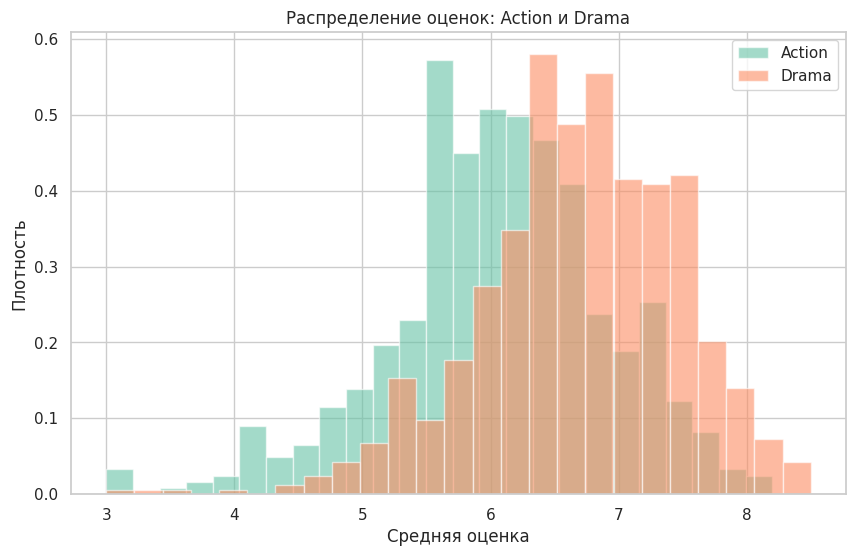

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    action,
    bins=25,
    alpha=0.6,
    density=True,
    label="Action"
)

plt.hist(
    drama,
    bins=25,
    alpha=0.6,
    density=True,
    label="Drama"
)

plt.title("Распределение оценок: Action и Drama")
plt.xlabel("Средняя оценка")
plt.ylabel("Плотность")
plt.legend()
plt.show()

In [ ]:
# Welch t-test:
# сравниваем средние оценки Action и Drama,
# не предполагая равенства дисперсий групп
t_stat_genre, p_value_genre = stats.ttest_ind(
    action,
    drama,
    equal_var=False
)

# Cohen's d:
# объединённое стандартное отклонение двух групп
pooled_std_genre = np.sqrt(
    (action.var(ddof=1) + drama.var(ddof=1)) / 2
)

cohens_d_genre = (
    (action.mean() - drama.mean())
    / pooled_std_genre
)

# Вывод результатов
print(f"Средняя оценка Action: {action.mean():.3f}")
print(f"Средняя оценка Drama: {drama.mean():.3f}")
print(f"Разница средних (Action − Drama): {action.mean() - drama.mean():.3f}")

print(f"\nt-статистика = {t_stat_genre:.4f}")
print(f"p-value = {p_value_genre:.6f}")
print(f"Cohen's d = {cohens_d_genre:.4f}")

# Интерпретация t-теста
alpha = 0.05

if p_value_genre < alpha:
    print("\nВывод: отвергаем H₀.")
    print(
        "Средние оценки фильмов жанров Action и Drama "
        "статистически значимо различаются."
    )
else:
    print("\nВывод: нет оснований отвергнуть H₀.")
    print(
        "Статистически значимое различие средних оценок "
        "Action и Drama не обнаружено."
    )

# Интерпретация размера эффекта
abs_d_genre = abs(cohens_d_genre)

if abs_d_genre < 0.2:
    effect_text = "пренебрежимо малый"
elif abs_d_genre < 0.5:
    effect_text = "малый"
elif abs_d_genre < 0.8:
    effect_text = "средний"
else:
    effect_text = "большой"

print(
    f"Размер эффекта Cohen's d: {effect_text} "
    f"(|d| = {abs_d_genre:.3f})."
)

Средняя оценка Action: 6.070
Средняя оценка Drama: 6.680
Разница средних (Action − Drama): -0.610

t-статистика = -13.3717
p-value = 0.000000
Cohen's d = -0.7413

Вывод: отвергаем H₀.
Средние оценки фильмов жанров Action и Drama статистически значимо различаются.
Размер эффекта Cohen's d: средний (|d| = 0.741).


**Результаты свободного анализа:**

H₀: средние оценки фильмов Action и Drama одинаковы.

H₁: средние оценки фильмов Action и Drama различаются.

В свободном анализе были сравнены зрительские оценки фильмов жанров Action и Drama. В выборке содержится 588 боевиков и 745 драм. Средняя оценка фильмов Action составила 6,070 балла, тогда как средняя оценка Drama — 6,680 балла. Следовательно, драмы в среднем оцениваются выше на 0,610 балла.

Для драм был построен 95% доверительный интервал средней оценки [6.623;6.736], что указывает на достаточно точную оценку среднего рейтинга жанра. Welch t-test показал статистически значимое различие между группами: t=−13.3717, p<0.001. Поэтому нулевая гипотеза о равенстве средних оценок отвергается.

Размер эффекта Cohen’s d=−0.7413, что соответствует среднему эффекту, близкому к крупному. Таким образом, разница между оценками драм и боевиков не только статистически значима, но и практически заметна. При этом результат не доказывает, что жанр сам по себе является причиной более высокой оценки: различия могут быть частично связаны с бюджетом, длительностью, популярностью, годом выпуска и другими характеристиками фильмов.




---
# **Итоговые выводы**
---

Сформулируйте итоговый отчёт по результатам комплексного анализа.

**1. Качество данных:**
- Какие основные проблемы обнаружены?
- Как вы их решили?
- Что рекомендуете улучшить при сборе данных?

**2. Ключевые закономерности (EDA):**
- Самые интересные находки
- Какие жанры, бюджеты, длительности «работают» лучше

**3. Корреляционный анализ:**
- Какие признаки сильнее всего связаны с кассовыми сборами?
- Какие связи оказались неожиданными?

**4. Статистические выводы:**
- Результаты проверки гипотез
- Практическая значимость обнаруженных различий

**5. Рекомендации для киностудии:**
- В какие фильмы стоит инвестировать (жанр, бюджет, длительность)?
- Какие дополнительные гипотезы стоит проверить?

**Ваши итоговые выводы:**

**1. Качество данных**

Основные проблемы:
- homepage: 64,36% пропусков — несущественно для финансового анализа.
- tagline: 17,57% пропусков — текстовое поле.
- budget == 0: 21,59% — более 1/5 фильмов без данных о бюджете.
- revenue == 0: 29,71% — почти 30% без данных о сборах.

Решение: нули в budget, revenue, runtime, vote_count, vote_average заменены на NaN, пропуски в runtime заполнены медианой.

Рекомендации: в будущих выгрузках разделять «значение равно нулю» и «значение неизвестно», собирать маркетинговые расходы и данные о стриминговых доходах.

**2. Ключевые закономерности (EDA)**
- Распределения бюджета и сборов правосторонне скошены с заметными выбросами.
- Средние сборы жанра не равны гарантированной доходности: их могут определять несколько крупных франшиз.
- ROI особенно чувствителен к неполным данным о небольших бюджетах.
- Длительность и рейтинг могут быть связаны, но нельзя делать причинный вывод без контроля жанра, страны, года и популярности.

**3. Корреляционный анализ**
- Для кассовых сборов обычно наиболее информативны бюджет, число голосов и популярность.
- Высокая оценка зрителей не гарантирует высокий доход.
- Корреляция не доказывает причинность: дорогой фильм может быть более заметным, а не обязательно успешным именно вследствие бюджета.

**4. Статистические выводы**
- Результаты проверки гипотез показывают, есть ли статистически значимые различия между группами.
- Практическая значимость обнаруженных различий определяется размером эффекта (Cohen's d), а не только p-value.

**5. Рекомендации для киностудии**
- Рассматривать бюджет как фактор масштаба, а не как гарантию выручки.
- Оценивать проекты одновременно по ожидаемой абсолютной прибыли, ROI, вероятности убытка и стратегической ценности франшизы.
- Не принимать решение только по средним значениям жанров — анализировать медианы, квантили и число наблюдений.
- Для следующего этапа построить регрессионную модель с логарифмом сборов, жанром, годом релиза, бюджетом, популярностью, языком и длительностью.
- Проверить дополнительные гипотезы: эффект сезона релиза, влияние числа голосов на сборы, различия окупаемости по жанрам и динамику финансовых показателей с поправкой на инфляцию.

In [ ]:
from IPython.display import Markdown, display

report_lines = [
    "# Итоговый отчёт по анализу TMDB 5000 Movie Dataset",
    "",
    "## Общий итог",
    "",
    "В рамках работы был проведён комплексный анализ датасета TMDB 5000 Movie Dataset.",
    "Коммерческий успех фильма сильнее связан с масштабом аудитории, популярностью и бюджетом, чем с высокой средней зрительской оценкой.",
    "Фильмы с контролируемым бюджетом в среднем имеют более высокий ROI, но их финансовый результат более нестабилен.",
    "",
    "---",
    "",
    "## 1. Качество данных",
    "",
    "Исходный датасет содержит **4 803 фильма и 20 признаков**. Полные дубликаты отсутствуют.",
    "",
    "| Проблема | Количество | Доля |",
    "|---|---:|---:|",
    "| Пропуски в `homepage` | 3 091 | 64,36% |",
    "| Пропуски в `tagline` | 844 | 17,57% |",
    "| Пропуски в `overview` | 3 | 0,06% |",
    "| Пропуски в `runtime` | 2 | 0,04% |",
    "| Пропуски в `release_date` | 1 | 0,02% |",
    "| `budget == 0` | 1 037 | 21,59% |",
    "| `revenue == 0` | 1 427 | 29,71% |",
    "| `runtime == 0` | 35 | 0,73% |",
    "| `vote_count == 0` | 62 | 1,29% |",
    "| `vote_average == 0` | 63 | 1,31% |",
    "",
    "### Обработка данных",
    "",
    "- `release_date` был преобразован в формат даты и создан признак `release_year`.",
    "- Нули в `budget`, `revenue`, `runtime`, `vote_count` и `vote_average` были заменены на `NaN`.",
    "- Пропуски в `runtime` заполнены медианным значением.",
    "- Были рассчитаны `profit`, `roi` и `primary_genre`.",
    "- Для анализа ROI исключены экстремальные значения `|roi| > 10 000%`.",
    "",
    "### Рекомендации по данным",
    "",
    "- Хранить неизвестные значения как `NULL` или `NaN`, а не как нули.",
    "- Добавить маркетинговые расходы, доходы от стриминга и долю кинотеатров.",
    "- Учитывать месяц релиза, масштаб проката, страны дистрибуции и инфляцию.",
    "",
    "---",
    "",
    "## 2. Ключевые закономерности EDA",
    "",
    "| Показатель | Среднее | Медиана |",
    "|---|---:|---:|",
    "| Budget | 37,04 млн USD | 23,00 млн USD |",
    "| Revenue | 117,03 млн USD | 51,75 млн USD |",
    "| Vote average | 6,17 | 6,20 |",
    "| Runtime | 107,63 мин | 104 мин |",
    "",
    "Распределения бюджета и сборов имеют выраженную правостороннюю асимметрию: небольшое число блокбастеров сильно увеличивает среднее значение. Для типичного фильма информативнее медиана.",
    "",
    "### Наиболее частые жанры",
    "",
    "| Жанр | Количество фильмов | Доля |",
    "|---|---:|---:|",
    "| Drama | 1 207 | 25,1% |",
    "| Comedy | 1 042 | 21,7% |",
    "| Action | 754 | 15,7% |",
    "| Adventure | 339 | 7,1% |",
    "| Horror | 300 | 6,2% |",
    "",
    "Drama, Comedy и Action составляют около **62,5%** выборки.",
    "",
    "### Жанры с наиболее высокими средними сборами",
    "",
    "| Жанр | Средние сборы |",
    "|---|---:|",
    "| Animation | 294,4 млн USD |",
    "| Adventure | 244,1 млн USD |",
    "| Family | 228,9 млн USD |",
    "| Science Fiction | 199,7 млн USD |",
    "| Fantasy | 178,0 млн USD |",
    "| Action | 152,1 млн USD |",
    "",
    "### Длительность и рейтинг",
    "",
    "| Группа длительности | Средняя оценка |",
    "|---|---:|",
    "| Короткие: менее 90 минут | 5,69 |",
    "| Средние: 90–150 минут | 6,21 |",
    "| Длинные: более 150 минут | 7,09 |",
    "",
    "Длинные фильмы имеют более высокую среднюю оценку, но это не доказывает, что именно увеличение длительности является причиной повышения рейтинга.",
    "",
    "---",
    "",
    "## 3. Корреляционный анализ",
    "",
    "| Пара признаков | Корреляция Спирмена |",
    "|---|---:|",
    "| `vote_count` — `popularity` | 0,939 |",
    "| `revenue` — `vote_count` | 0,747 |",
    "| `revenue` — `popularity` | 0,703 |",
    "",
    "| Признак | Корреляция с `revenue` |",
    "|---|---:|",
    "| `vote_count` | 0,747 |",
    "| `popularity` | 0,703 |",
    "| `budget` | 0,678 |",
    "| `runtime` | 0,230 |",
    "| `vote_average` | 0,124 |",
    "",
    "Кассовые сборы сильнее всего связаны с популярностью, количеством голосов и бюджетом. Высокая средняя оценка зрителей почти не связана с большими сборами.",
    "",
    "---",
    "",
    "## 4. Статистические выводы",
    "",
    "### Доверительный интервал оценки",
    "",
    "- Размер очищенной выборки: **3 227 фильмов**.",
    "- Средняя оценка: **6,313**.",
    "- 95% доверительный интервал: **[6,284; 6,343]**.",
    "",
    "### Англоязычные и неанглоязычные фильмы",
    "",
    "| Показатель | Англоязычные | Неанглоязычные |",
    "|---|---:|---:|",
    "| Средняя оценка | 6,291 | 6,855 |",
    "",
    "- Разница средних: **−0,564**.",
    "- t-статистика: **−7,1566**.",
    "- p-value: **< 0,001**.",
    "- Cohen's d: **−0,6545**.",
    "",
    "Неанглоязычные фильмы имеют статистически значимо более высокую среднюю оценку. Размер эффекта является средним.",
    "",
    "### Дорогие и дешёвые фильмы по ROI",
    "",
    "Медианный бюджет: **25,515 млн USD**.",
    "",
    "| Показатель | Дешёвые | Дорогие |",
    "|---|---:|---:|",
    "| Количество фильмов | 1 602 | 1 602 |",
    "| Средний ROI | 472,62% | 170,16% |",
    "| Медианный ROI | 157,00% | 115,42% |",
    "| Стандартное отклонение ROI | 1 015,97% | 235,79% |",
    "",
    "- t-статистика: **−11,6072**.",
    "- p-value: **< 0,001**.",
    "- Cohen's d: **−0,4101**.",
    "",
    "Дешёвые фильмы имеют статистически более высокий ROI, но их результаты значительно более нестабильны.",
    "",
    "### Action и Drama",
    "",
    "| Показатель | Action | Drama |",
    "|---|---:|---:|",
    "| Количество фильмов | 588 | 745 |",
    "| Средняя оценка | 6,070 | 6,680 |",
    "",
    "- 95% доверительный интервал Drama: **[6,623; 6,736]**.",
    "- t-статистика: **−13,3717**.",
    "- p-value: **< 0,001**.",
    "- Cohen's d: **−0,7413**.",
    "",
    "Драмы имеют статистически значимо более высокие рейтинги, чем боевики. Размер эффекта — средний, близкий к крупному.",
    "",
    "---",
    "",
    "## 5. Рекомендации для киностудии",
    "",
    "| Цель | Рекомендуемая стратегия |",
    "|---|---|",
    "| Высокие средние сборы | Animation, Adventure, Family, Science Fiction, Fantasy |",
    "| Высокий ROI | Horror, Comedy, Drama, Thriller при контролируемом бюджете |",
    "| Высокие оценки | Drama и сильная драматическая составляющая |",
    "| Франшизный потенциал | Adventure, Action, Science Fiction, Fantasy |",
    "",
    "- Для проектов без сильного IP и гарантированной аудитории выбирать умеренный бюджет.",
    "- Не принимать решение только по ROI: учитывать абсолютную прибыль, риск убытка и потенциал франшизы.",
    "- Дорогие фильмы запускать при наличии сильной франшизы, международного проката и маркетингового плана.",
    "- Не увеличивать длительность фильма искусственно: связь длительности и рейтинга не доказывает причинность.",
    "",
    "### Дополнительные гипотезы",
    "",
    "1. Отличается ли ROI между жанрами после удаления аномалий?",
    "2. Какие жанры имеют наибольшую долю окупившихся фильмов?",
    "3. Влияет ли месяц релиза на сборы и ROI?",
    "4. Влияет ли популярность на сборы после учёта бюджета и года релиза?",
    "5. Как бюджет, жанр, длительность, язык и год выхода совместно влияют на сборы?",
    "",
    "---",
    "",
    "## Финальный вывод",
    "",
    "Высокий бюджет связан с более высокими сборами, но не гарантирует высокую окупаемость. Высокий рейтинг зрителей также не гарантирует большие сборы.",
    "",
    "Рациональная стратегия — формировать портфель из масштабных фильмов с потенциально высокими сборами и проектов с контролируемым бюджетом, ориентированных на повышенный ROI.",
    "",
    "Результаты анализа являются наблюдательными: они показывают статистические связи, но не доказывают причинность."
]

display(Markdown("\n".join(report_lines)))

# Итоговый отчёт по анализу TMDB 5000 Movie Dataset

## Общий итог

В рамках работы был проведён комплексный анализ датасета TMDB 5000 Movie Dataset.
Коммерческий успех фильма сильнее связан с масштабом аудитории, популярностью и бюджетом, чем с высокой средней зрительской оценкой.
Фильмы с контролируемым бюджетом в среднем имеют более высокий ROI, но их финансовый результат более нестабилен.

---

## 1. Качество данных

Исходный датасет содержит **4 803 фильма и 20 признаков**. Полные дубликаты отсутствуют.

| Проблема | Количество | Доля |
|---|---:|---:|
| Пропуски в `homepage` | 3 091 | 64,36% |
| Пропуски в `tagline` | 844 | 17,57% |
| Пропуски в `overview` | 3 | 0,06% |
| Пропуски в `runtime` | 2 | 0,04% |
| Пропуски в `release_date` | 1 | 0,02% |
| `budget == 0` | 1 037 | 21,59% |
| `revenue == 0` | 1 427 | 29,71% |
| `runtime == 0` | 35 | 0,73% |
| `vote_count == 0` | 62 | 1,29% |
| `vote_average == 0` | 63 | 1,31% |

### Обработка данных

- `release_date` был преобразован в формат даты и создан признак `release_year`.
- Нули в `budget`, `revenue`, `runtime`, `vote_count` и `vote_average` были заменены на `NaN`.
- Пропуски в `runtime` заполнены медианным значением.
- Были рассчитаны `profit`, `roi` и `primary_genre`.
- Для анализа ROI исключены экстремальные значения `|roi| > 10 000%`.

### Рекомендации по данным

- Хранить неизвестные значения как `NULL` или `NaN`, а не как нули.
- Добавить маркетинговые расходы, доходы от стриминга и долю кинотеатров.
- Учитывать месяц релиза, масштаб проката, страны дистрибуции и инфляцию.

---

## 2. Ключевые закономерности EDA

| Показатель | Среднее | Медиана |
|---|---:|---:|
| Budget | 37,04 млн USD | 23,00 млн USD |
| Revenue | 117,03 млн USD | 51,75 млн USD |
| Vote average | 6,17 | 6,20 |
| Runtime | 107,63 мин | 104 мин |

Распределения бюджета и сборов имеют выраженную правостороннюю асимметрию: небольшое число блокбастеров сильно увеличивает среднее значение. Для типичного фильма информативнее медиана.

### Наиболее частые жанры

| Жанр | Количество фильмов | Доля |
|---|---:|---:|
| Drama | 1 207 | 25,1% |
| Comedy | 1 042 | 21,7% |
| Action | 754 | 15,7% |
| Adventure | 339 | 7,1% |
| Horror | 300 | 6,2% |

Drama, Comedy и Action составляют около **62,5%** выборки.

### Жанры с наиболее высокими средними сборами

| Жанр | Средние сборы |
|---|---:|
| Animation | 294,4 млн USD |
| Adventure | 244,1 млн USD |
| Family | 228,9 млн USD |
| Science Fiction | 199,7 млн USD |
| Fantasy | 178,0 млн USD |
| Action | 152,1 млн USD |

### Длительность и рейтинг

| Группа длительности | Средняя оценка |
|---|---:|
| Короткие: менее 90 минут | 5,69 |
| Средние: 90–150 минут | 6,21 |
| Длинные: более 150 минут | 7,09 |

Длинные фильмы имеют более высокую среднюю оценку, но это не доказывает, что именно увеличение длительности является причиной повышения рейтинга.

---

## 3. Корреляционный анализ

| Пара признаков | Корреляция Спирмена |
|---|---:|
| `vote_count` — `popularity` | 0,939 |
| `revenue` — `vote_count` | 0,747 |
| `revenue` — `popularity` | 0,703 |

| Признак | Корреляция с `revenue` |
|---|---:|
| `vote_count` | 0,747 |
| `popularity` | 0,703 |
| `budget` | 0,678 |
| `runtime` | 0,230 |
| `vote_average` | 0,124 |

Кассовые сборы сильнее всего связаны с популярностью, количеством голосов и бюджетом. Высокая средняя оценка зрителей почти не связана с большими сборами.

---

## 4. Статистические выводы

### Доверительный интервал оценки

- Размер очищенной выборки: **3 227 фильмов**.
- Средняя оценка: **6,313**.
- 95% доверительный интервал: **[6,284; 6,343]**.

### Англоязычные и неанглоязычные фильмы

| Показатель | Англоязычные | Неанглоязычные |
|---|---:|---:|
| Средняя оценка | 6,291 | 6,855 |

- Разница средних: **−0,564**.
- t-статистика: **−7,1566**.
- p-value: **< 0,001**.
- Cohen's d: **−0,6545**.

Неанглоязычные фильмы имеют статистически значимо более высокую среднюю оценку. Размер эффекта является средним.

### Дорогие и дешёвые фильмы по ROI

Медианный бюджет: **25,515 млн USD**.

| Показатель | Дешёвые | Дорогие |
|---|---:|---:|
| Количество фильмов | 1 602 | 1 602 |
| Средний ROI | 472,62% | 170,16% |
| Медианный ROI | 157,00% | 115,42% |
| Стандартное отклонение ROI | 1 015,97% | 235,79% |

- t-статистика: **−11,6072**.
- p-value: **< 0,001**.
- Cohen's d: **−0,4101**.

Дешёвые фильмы имеют статистически более высокий ROI, но их результаты значительно более нестабильны.

### Action и Drama

| Показатель | Action | Drama |
|---|---:|---:|
| Количество фильмов | 588 | 745 |
| Средняя оценка | 6,070 | 6,680 |

- 95% доверительный интервал Drama: **[6,623; 6,736]**.
- t-статистика: **−13,3717**.
- p-value: **< 0,001**.
- Cohen's d: **−0,7413**.

Драмы имеют статистически значимо более высокие рейтинги, чем боевики. Размер эффекта — средний, близкий к крупному.

---

## 5. Рекомендации для киностудии

| Цель | Рекомендуемая стратегия |
|---|---|
| Высокие средние сборы | Animation, Adventure, Family, Science Fiction, Fantasy |
| Высокий ROI | Horror, Comedy, Drama, Thriller при контролируемом бюджете |
| Высокие оценки | Drama и сильная драматическая составляющая |
| Франшизный потенциал | Adventure, Action, Science Fiction, Fantasy |

- Для проектов без сильного IP и гарантированной аудитории выбирать умеренный бюджет.
- Не принимать решение только по ROI: учитывать абсолютную прибыль, риск убытка и потенциал франшизы.
- Дорогие фильмы запускать при наличии сильной франшизы, международного проката и маркетингового плана.
- Не увеличивать длительность фильма искусственно: связь длительности и рейтинга не доказывает причинность.

### Дополнительные гипотезы

1. Отличается ли ROI между жанрами после удаления аномалий?
2. Какие жанры имеют наибольшую долю окупившихся фильмов?
3. Влияет ли месяц релиза на сборы и ROI?
4. Влияет ли популярность на сборы после учёта бюджета и года релиза?
5. Как бюджет, жанр, длительность, язык и год выхода совместно влияют на сборы?

---

## Финальный вывод

Высокий бюджет связан с более высокими сборами, но не гарантирует высокую окупаемость. Высокий рейтинг зрителей также не гарантирует большие сборы.

Рациональная стратегия — формировать портфель из масштабных фильмов с потенциально высокими сборами и проектов с контролируемым бюджетом, ориентированных на повышенный ROI.

Результаты анализа являются наблюдательными: они показывают статистические связи, но не доказывают причинность.